# Rock-Paper-Scissors Classifier - A Complete Deep-Learning Walkthrough

**A simple notebook for absolute beginners in deep learning, computer vision.**

This notebook builds a Convolutional Neural Network (CNN) that learns to recognize hand gestures: rock, paper, or scissors. We start from zero — assuming you don't know what a CNN is, what a tensor is, or how a neural network learns — and walk through every single concept and every single line of code.

By the end you will understand:

- What deep learning, computer vision, and CNNs actually are
- How images become numbers a computer can work with
- What every layer in our model does, with diagrams
- How the model actually learns through forward and backward passes
- How to read training curves to diagnose your model
- How to save the trained model and use it to predict on new images

Read slowly. Run each cell. Re-read sections. The goal isn't to finish — it's to *understand*.

---

## Table of contents

1. [The big picture — AI, ML, DL, and where CNNs fit](#part1)
2. [How a computer sees an image](#part2)
3. [The neuron and the artificial neural network](#part3)
4. [Why ANNs fail at images, and the CNN's three big ideas](#part4)
5. [The convolution operation explained](#part5)
6. [The full pipeline of our project](#part6)
7. [Setting up — imports and constants](#part7)
8. [Loading the images — train, validation, test](#part8)
9. [Optimizing the data pipeline](#part9)
10. [Data augmentation — getting more from less](#part10)
11. [Building the CNN — every layer dissected](#part11)
12. [Compiling — loss, optimizer, metrics](#part12)
13. [Training — the forward and backward pass](#part13)
14. [Evaluating on the test set](#part14)
15. [Reading training curves](#part15)
16. [Saving the model](#part16)
17. [Predicting on a new image](#part17)
18. [Where to go from here](#part18)

---

<a id="part1"></a>
## 1. The big picture — AI, ML, DL, and where CNNs fit


Before any code, you need a mental map. Three terms get tossed around as if they were the same thing. They are not.

**Artificial Intelligence (AI)** is the umbrella — any system that mimics intelligence. It includes everything from old-school chess engines that follow hand-written rules to modern language models.

**Machine Learning (ML)** is a subset of AI where the system *learns patterns from data* instead of following hand-coded rules. Linear regression, decision trees, and random forests are all ML.

**Deep Learning (DL)** is a subset of ML that uses *multi-layer neural networks*. The word "deep" just means many layers stacked. Deep learning has come to dominate problems involving images, text, audio, and video.

A **CNN** (Convolutional Neural Network) is a specific kind of deep network designed for images. That is what we will build.

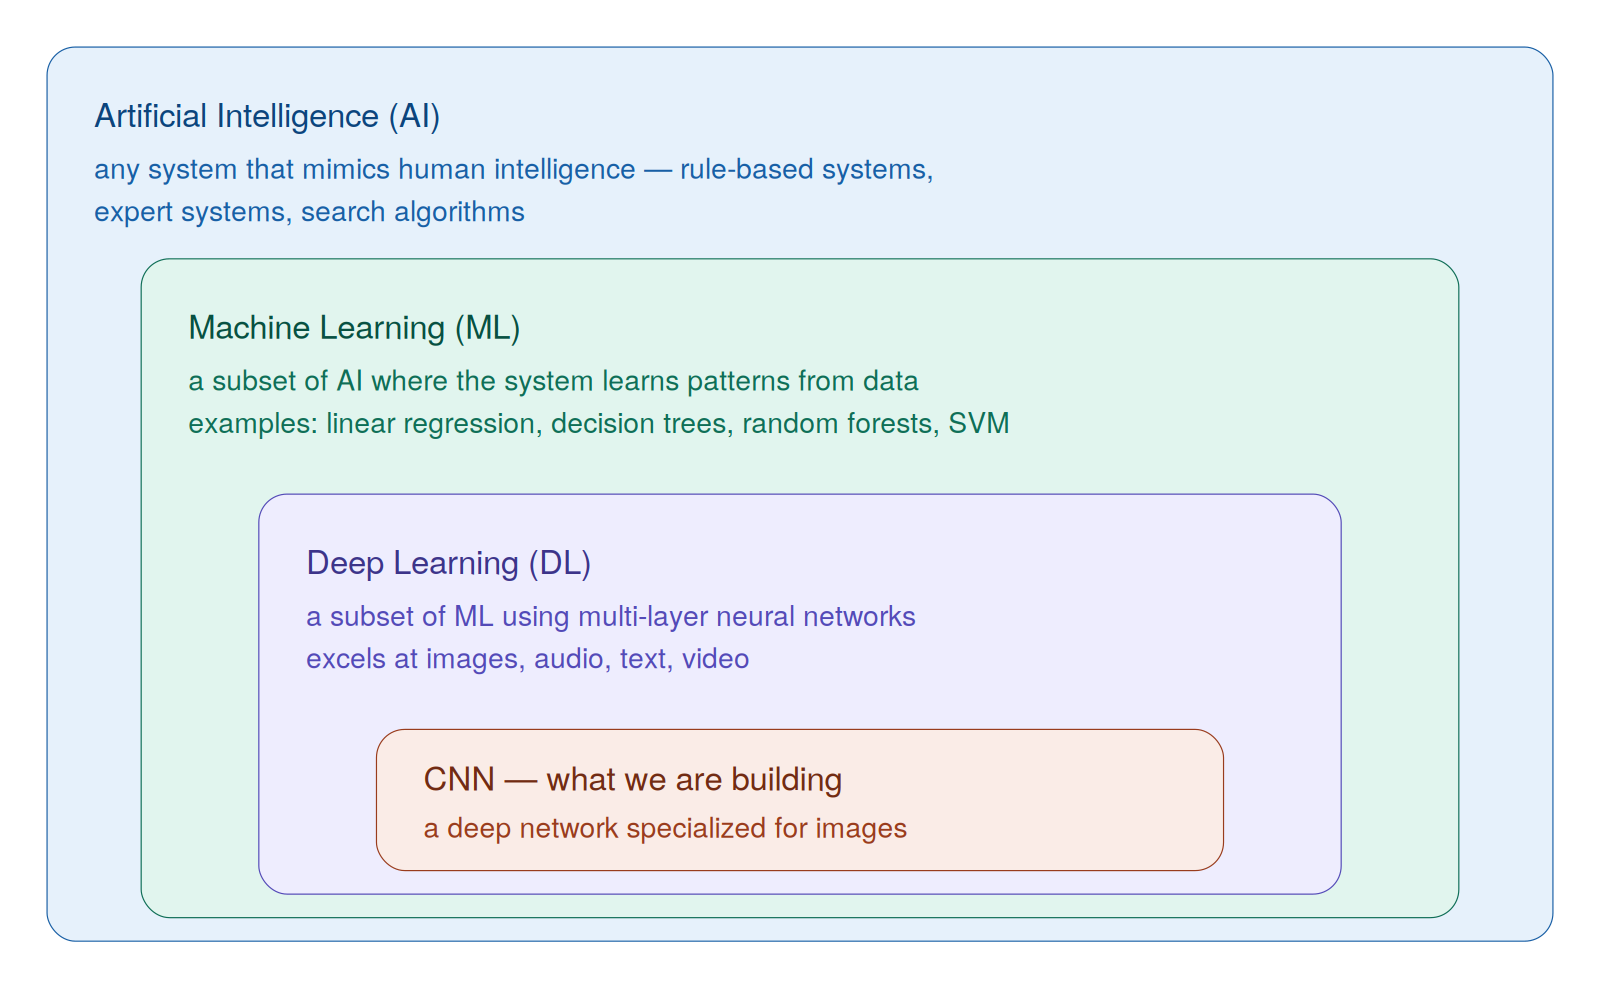

*AI is the umbrella, ML is a subset of AI, DL is a subset of ML, CNN is a specific kind of DL model.*

<a id="part2"></a>
## 2. How a computer sees an image


A computer cannot see. It can only do math. So before we can train a model on images, we need to understand what an image even *is* to a computer.

**An image is a grid of numbers.** Each pixel in a black-and-white image is a single number from 0 (black) to 255 (white). For a color image, each pixel is *three* numbers: how much red, how much green, how much blue. Stack those three grids on top of each other and you get a color image.

A 150×150 color photo therefore becomes a 3D array of shape `(150, 150, 3)` — that's 150 rows tall, 150 columns wide, 3 color channels deep, totaling 67,500 numbers.

The technical name for this kind of N-dimensional array is a **tensor**. The word *TensorFlow* in our library name comes from this. Throughout this notebook you'll hear "tensor of shape (X, Y, Z)" — that's just shorthand for "an array with X rows, Y columns, Z deep."

When we train on multiple images at once, we stack them into a 4D tensor: `(batch_size, height, width, channels)`. That fourth dimension says "which image in the batch."

Pixel values arrive in `[0, 255]`. Later we'll divide every pixel by 255 so they're in `[0, 1]` — neural networks learn much better when inputs are small numbers.

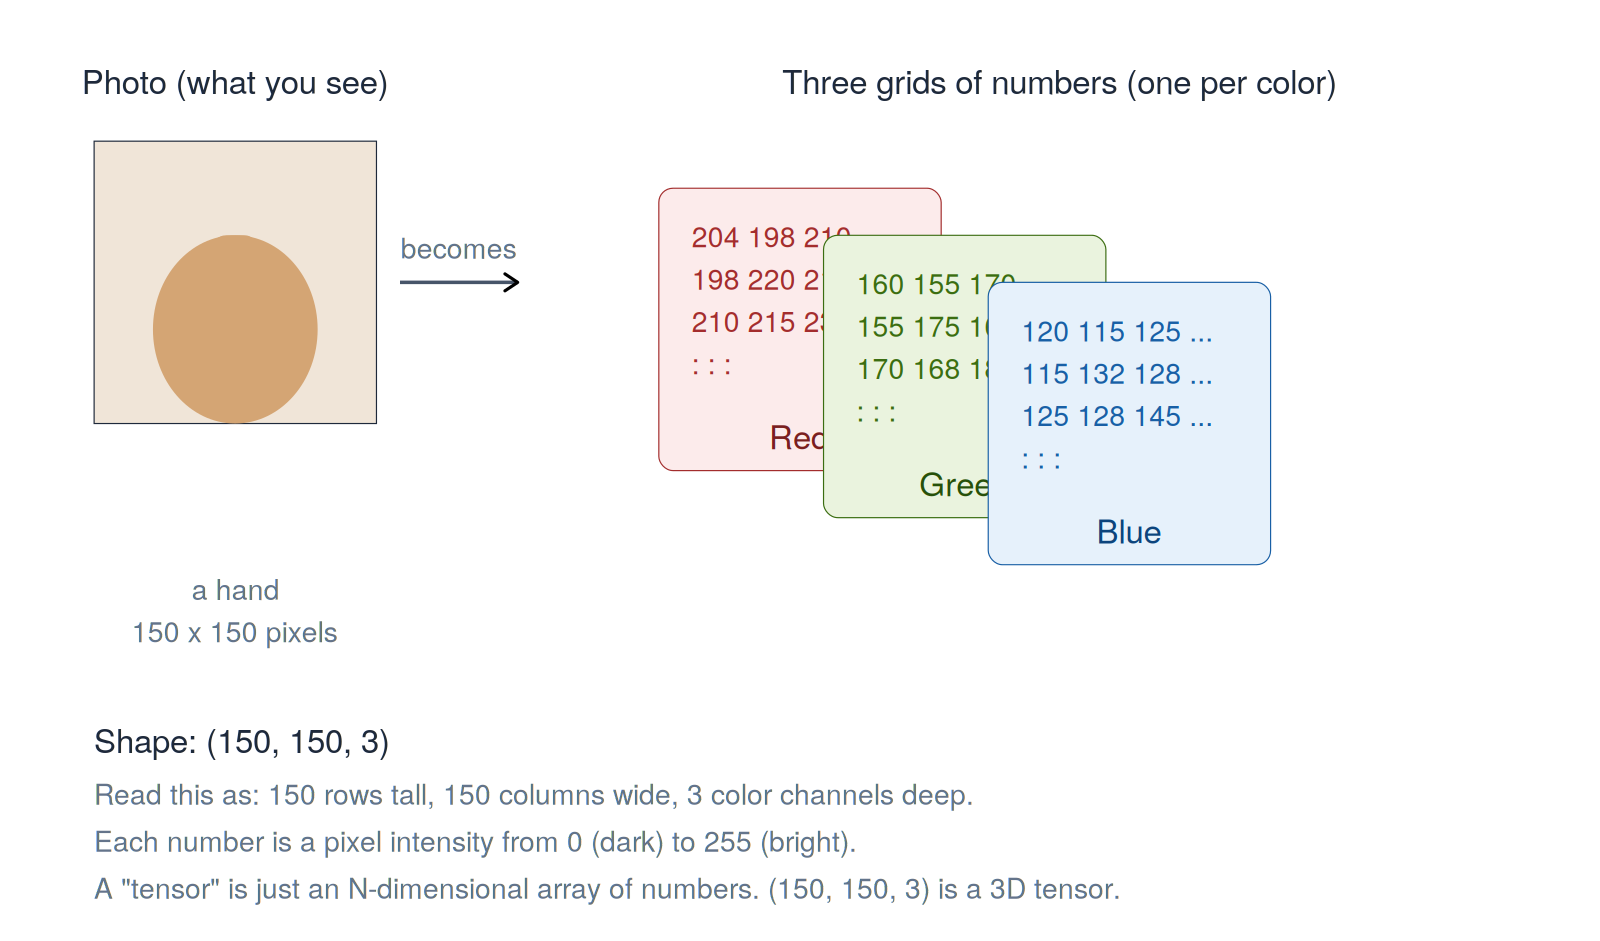

*A color image becomes three stacked grids of numbers — one each for red, green, and blue.*

<a id="part3"></a>
## 3. The neuron and the artificial neural network


A **neuron** is the building block of every neural network. It's surprisingly simple.

A neuron takes several inputs (numbers), multiplies each one by a *weight*, sums them up, adds a *bias*, and runs the result through an *activation function* (like ReLU, which we'll explain soon). The output is one number.

Formula: `output = activation(w₁·x₁ + w₂·x₂ + w₃·x₃ + b)`

The **weights** (w) and the **bias** (b) are the *learnable* parts. They start as random numbers. During training, the network nudges them — over millions of tiny adjustments — to make predictions more and more accurate.

A neural network is just thousands of these tiny units wired together in layers. Every "deep" model you hear about — from image classifiers to language models — is built on this same simple unit.

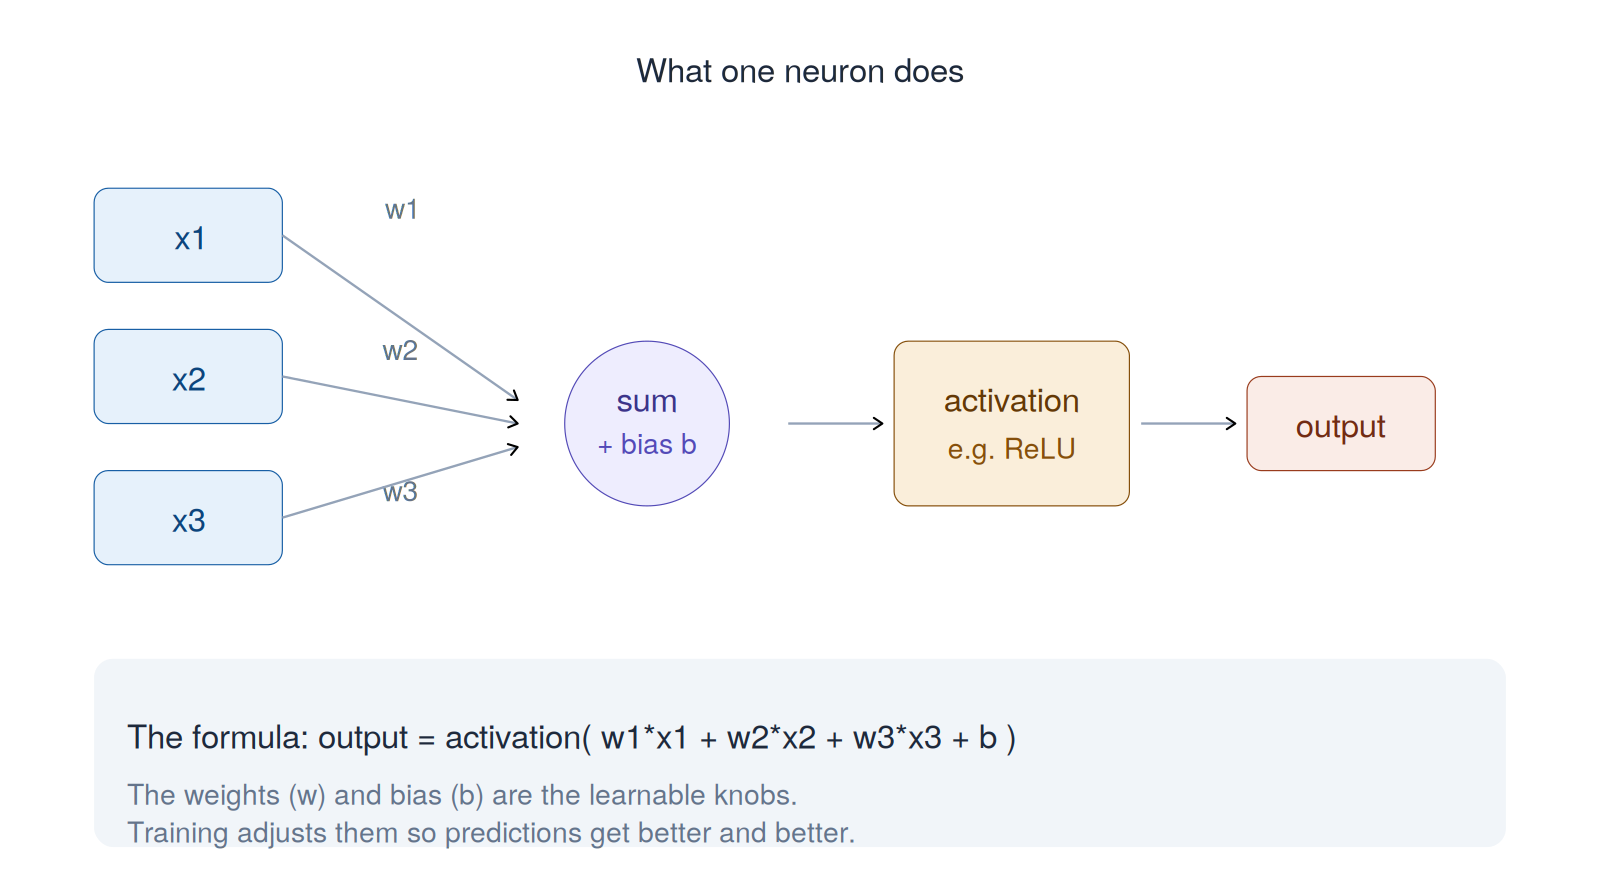

*One neuron: weighted sum of inputs, plus bias, through an activation function. That's it.*

Stack neurons in **layers**. Connect every neuron in one layer to every neuron in the next. That's a fully-connected ANN — also called a multi-layer perceptron (MLP).

Information flows left to right:
- **Input layer**: receives the raw data (e.g. pixel values).
- **Hidden layers**: do the actual learning.
- **Output layer**: produces the prediction (e.g. probabilities for each class).

More layers = more depth = ability to learn more complex patterns. But also more weights to train and more risk of overfitting.

ANNs work great for tabular data (rows and columns, like a spreadsheet of housing prices). For images, they have a serious problem — which we'll explain in the next section.

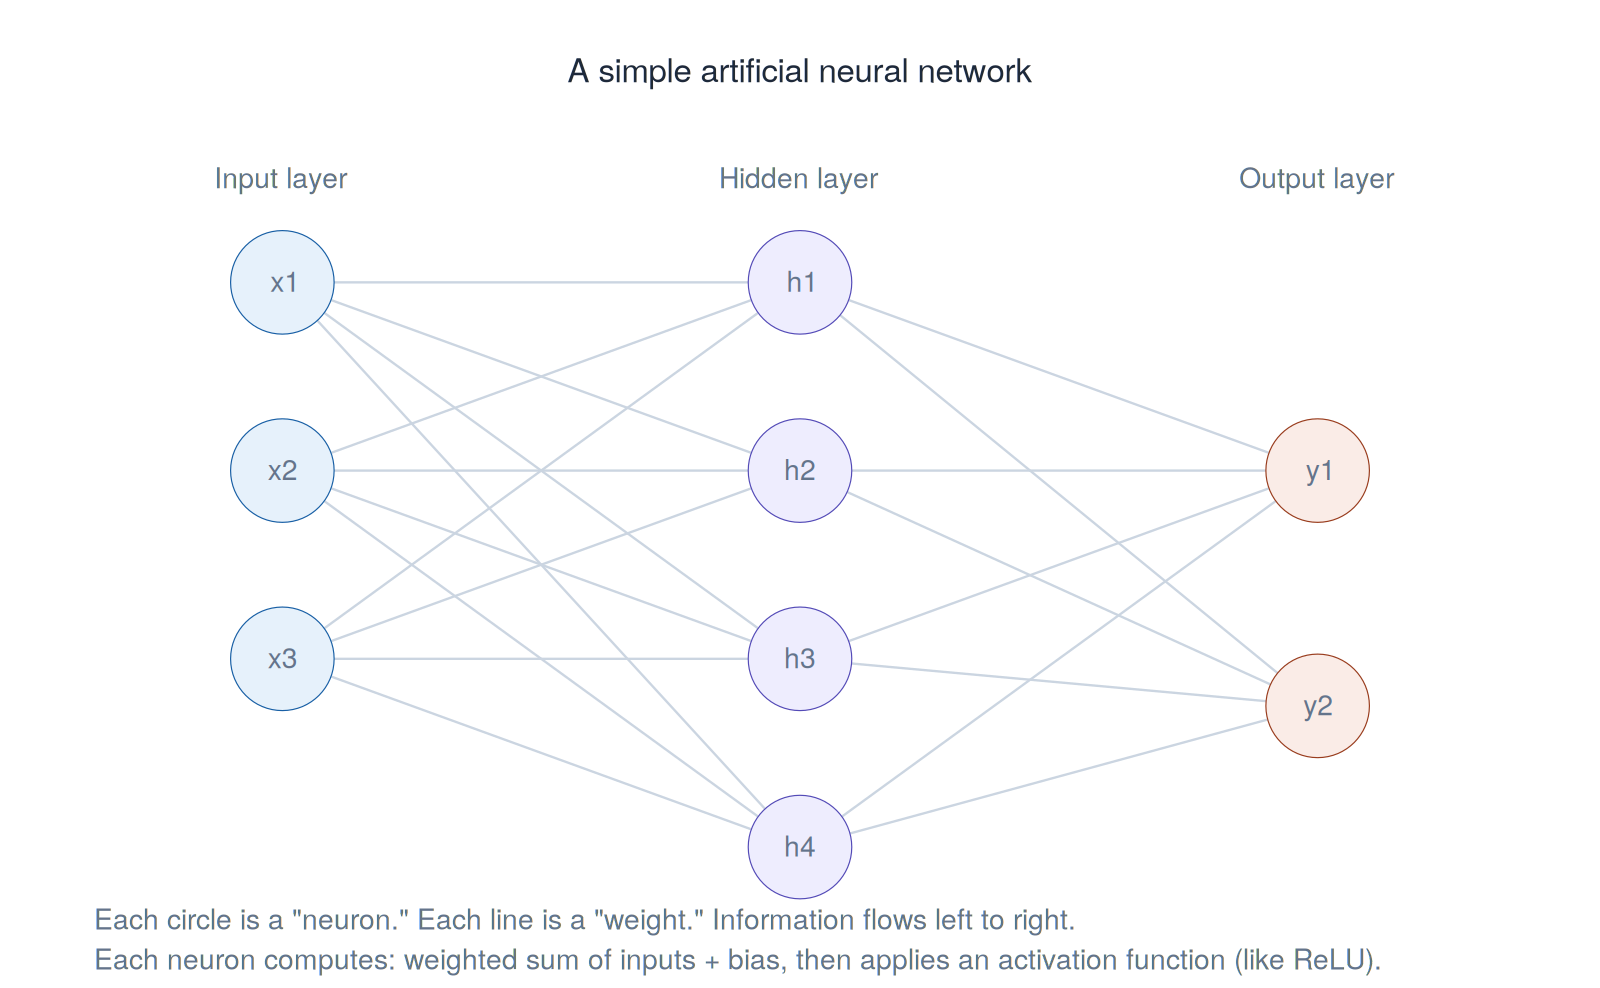

*A simple feedforward ANN with one hidden layer. Each line is a learnable weight.*

<a id="part4"></a>
## 4. Why ANNs fail at images, and the CNN's three big ideas

If you flatten a 150×150×3 image into a vector of 67,500 numbers and feed it to a fully-connected ANN, three things break:

**Way too many parameters.** A first hidden layer of just 1000 neurons would need 67.5 *million* weights. The model overfits instantly and is impossibly slow to train.

**Position doesn't transfer.** The ANN treats the pixel at row 10, column 10 as totally unrelated to the pixel at row 10, column 11. It would have to relearn what "hand" looks like at every possible position. Wasteful.

**Spatial structure is lost.** Flattening throws away the 2D layout. Neighboring pixels carry meaning together — eyes, edges, curves are *local* patterns. ANNs ignore locality.

The **CNN** fixes all three problems with three big ideas:

1. **Local receptive fields**: each filter only looks at a small patch (like 3×3 pixels) at a time. Matches how images actually work — meaning is local.
2. **Weight sharing**: the same filter slides across the whole image. A vertical-edge detector at top-left also works at bottom-right. Million-fold parameter reduction.
3. **Hierarchical composition**: stack many conv layers. Early layers learn edges. Middle layers combine edges into textures and parts. Deep layers combine parts into whole objects.

Let's see exactly what one convolution does.

<a id="part5"></a>
## 5. The convolution operation explained


A **filter** (also called a *kernel*) is a small grid of learnable numbers — typically 3×3 or 5×5. The filter slides across the input image. At each position:

1. Multiply each filter cell by the input pixel underneath it (element-wise).
2. Sum all those products into a single number.
3. That single number becomes one cell of the output, called a **feature map**.

Then slide the filter one step right, repeat. Reach the end of the row, drop down one step, start over from the left. Eventually you've covered the entire image.

The picture below shows this for a simple vertical-edge detector filter `[[-1, 0, +1], [-1, 0, +1], [-1, 0, +1]]`. Where the input has a vertical edge (dark on the left, light on the right), the multiplication produces a high positive number. Elsewhere, near zero.

**The magic**: the network learns the filter values automatically. We never tell it "look for vertical edges" — it discovers that those are useful.

A single conv layer doesn't use just one filter. It uses many — typically 32, 64, 128 different filters, each detecting a different pattern. Each filter produces its own feature map, so the output of a conv layer has as many channels as there are filters.

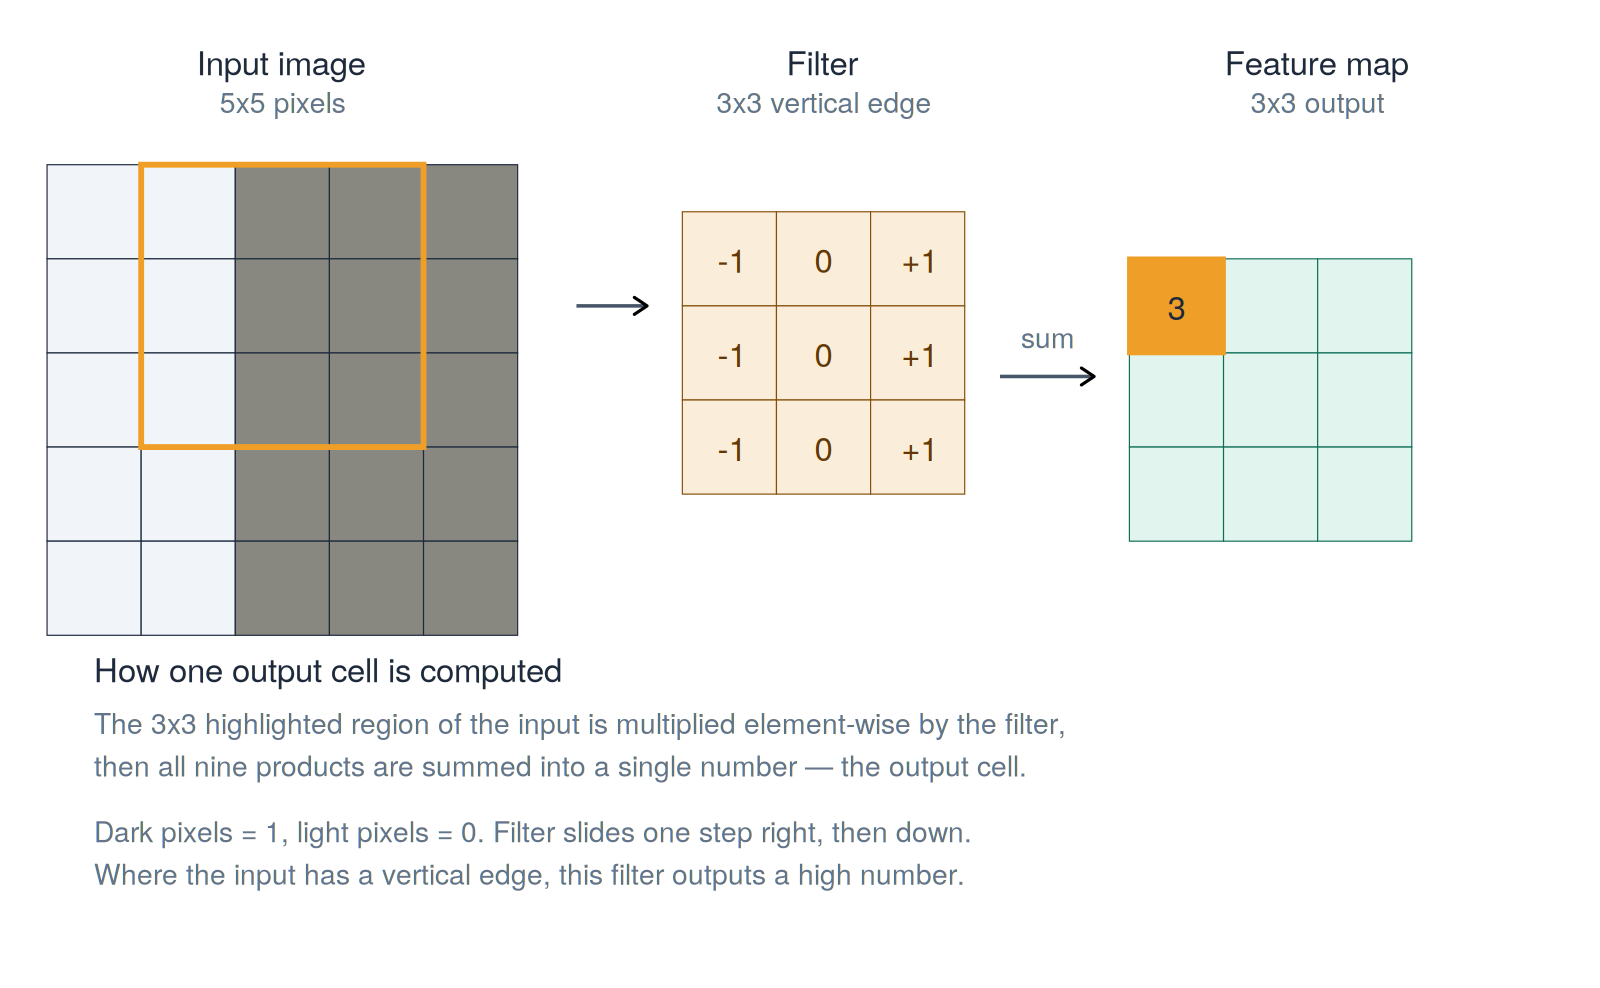

*One filter slides across the input. At each spot: multiply, sum, write to output.*

Stack many conv layers. Between them, **pooling** layers shrink the spatial size while keeping the strongest signals.

After a few rounds of conv → pool → conv → pool, the spatial dimensions are small but the channel depth is large. We **flatten** the 3D tensor into a 1D vector and feed it to a few fully-connected (Dense) layers that produce class probabilities.

The pattern is universal across image classifiers: the first half *extracts features* (conv + pool), the second half *makes decisions* (flatten + dense + softmax).

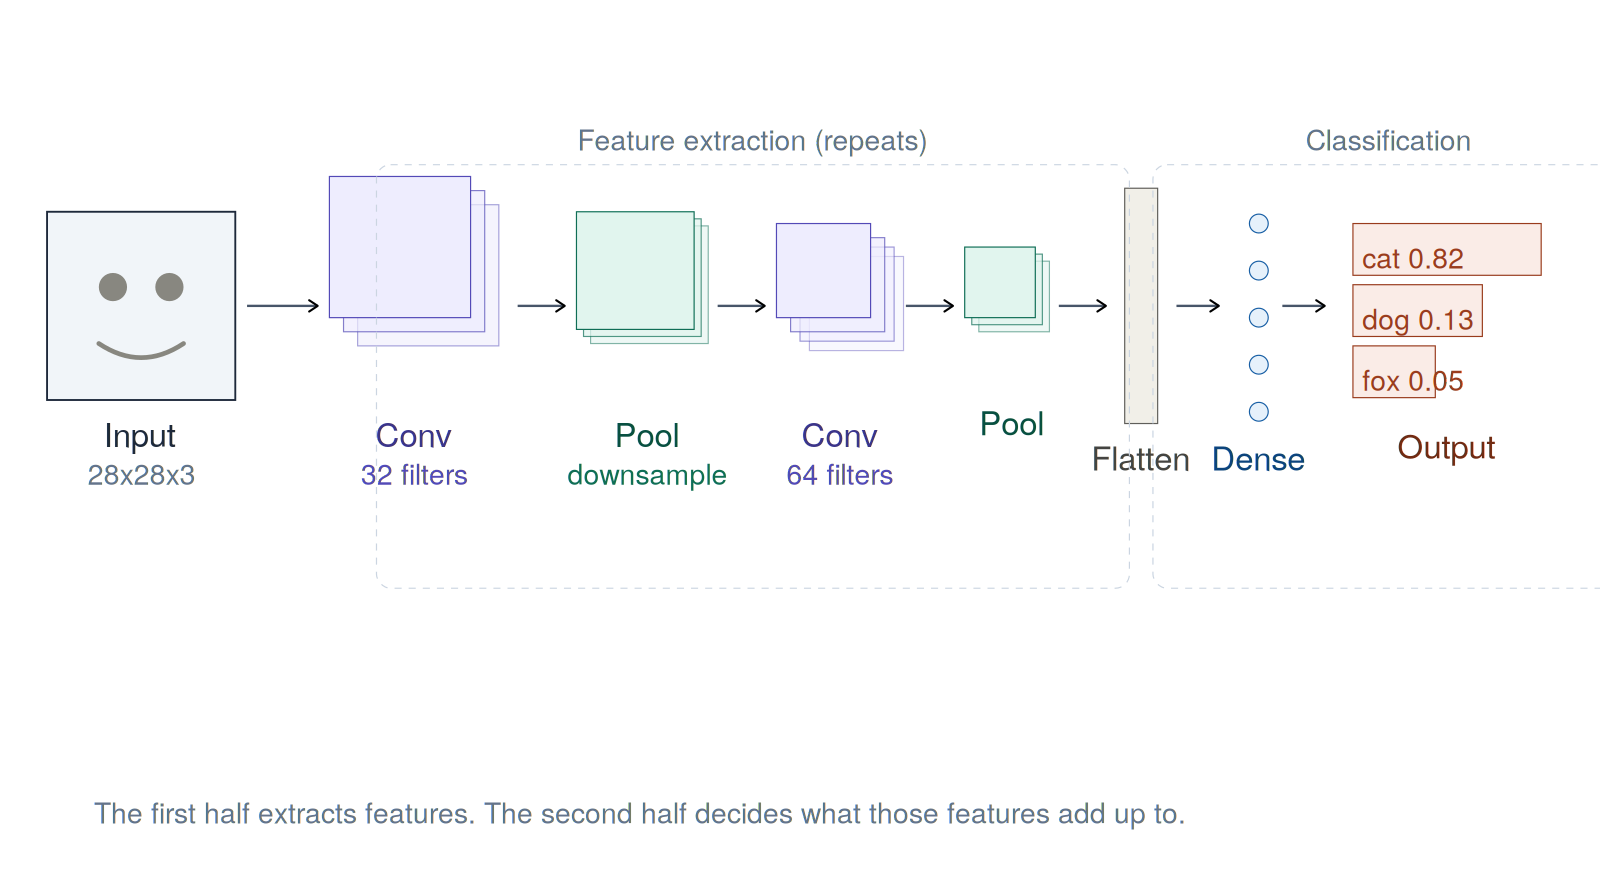

*The shape of every CNN: conv-pool repeating, then flatten, then dense, then output.*

The most beautiful thing about CNNs is what each layer learns *on its own*. Nobody programs this hierarchy — it emerges automatically during training.

- **Layer 1** fires on the simplest patterns: lines at different angles, color blobs.
- **Layer 2** combines those into curves, corners, dots, stripes.
- **Layer 3** combines textures into recognizable parts: an eye, a wheel, a leaf.
- **Layer 4** combines parts into whole objects: cat, dog, car.

This is identical to how our biological visual cortex processes what we see. Edges → contours → parts → objects.

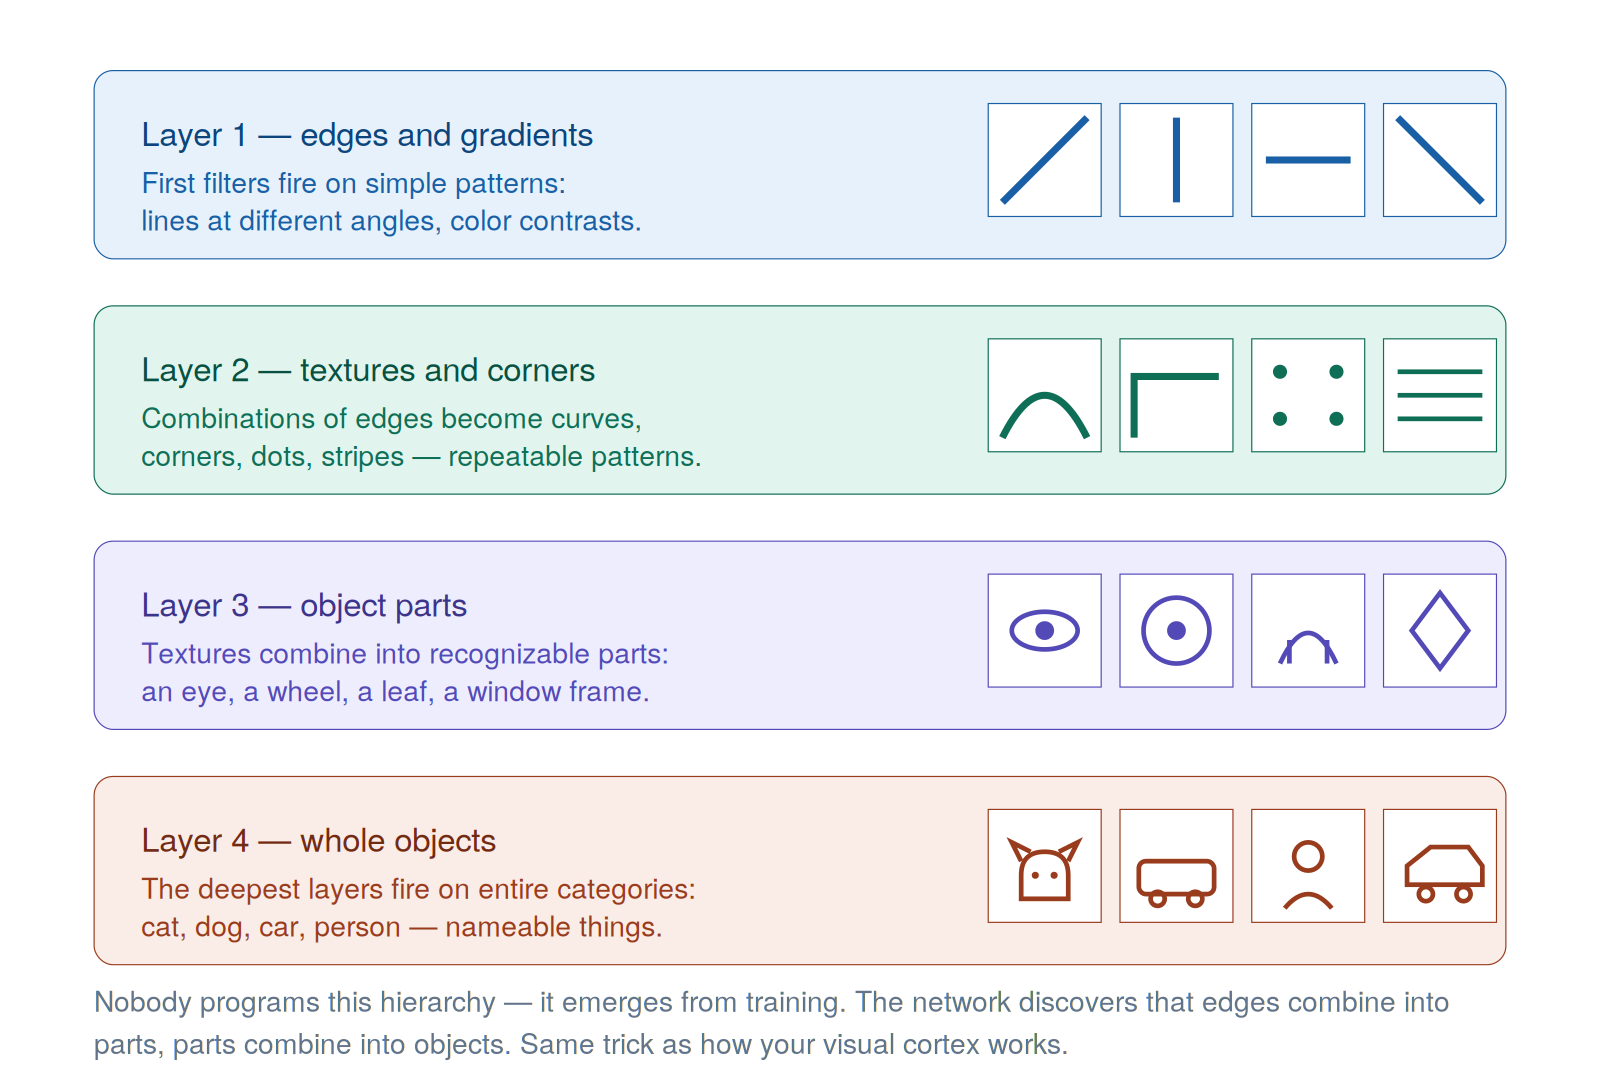

*Each layer builds on the one below — edges become parts become objects.*

<a id="part6"></a>
## 6. The full pipeline of our project


Before we touch a single line of code, here's the entire pipeline we will build. Every numbered block matches a section below — refer back to this diagram whenever you lose the thread.

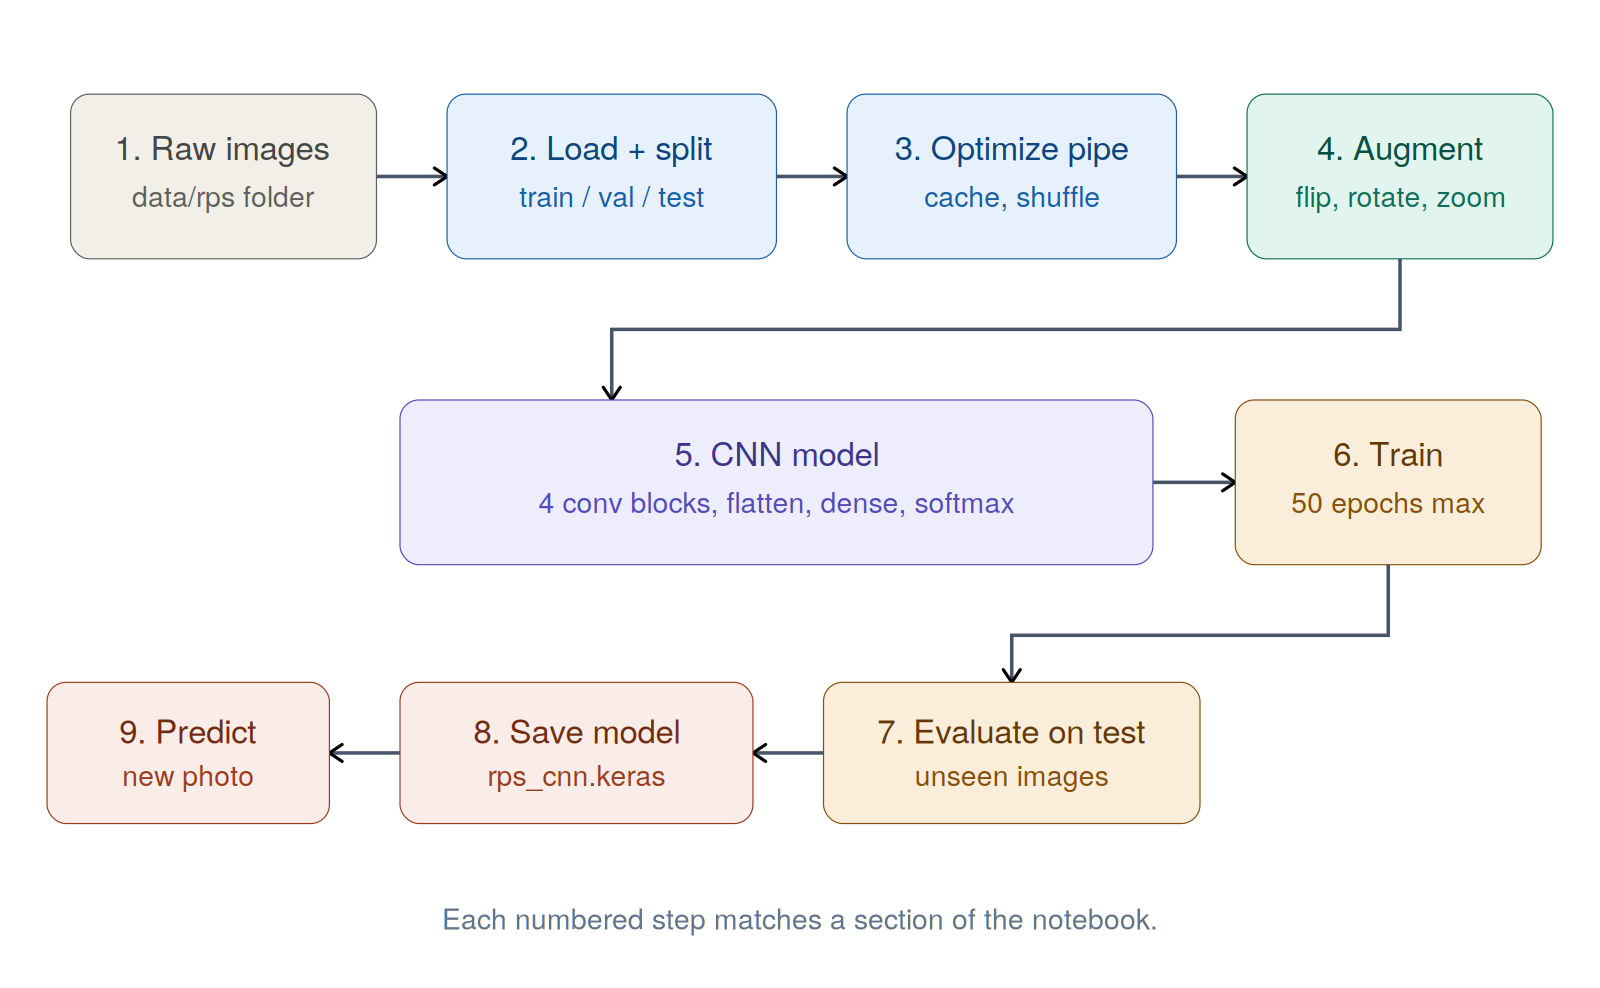

*Nine steps: load → split → optimize → augment → build → train → evaluate → save → predict.*

<a id="part7"></a>
## 7. Setting up — imports and constants

Three libraries do all the heavy lifting:

- **`tensorflow`** is a low-level math library by Google. Works with big arrays of numbers, runs on GPUs (10-100× faster than CPUs for this kind of work), and computes gradients automatically (which is how the model learns).
- **`keras`** sits on top of TensorFlow as a friendly high-level API. Lets you write a CNN in 10 lines instead of 200. `keras.layers` gives you ready-made building blocks: `Conv2D`, `MaxPooling2D`, `Dense`, etc.
- **`matplotlib.pyplot`** is the standard Python plotting library. We'll use it at the end to draw training curves.

In [ ]:
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

Now two constants that control everything downstream.

`IMAGE_SIZE = (150, 150)` — every photo will be resized to 150×150 pixels. Real-world photos come in all sizes, but a neural network needs a fixed input shape. We pick one and force everything to it.

`BATCH_SIZE = 32` — the model will look at 32 images at a time during training. This is called a *mini-batch*. Why 32? GPUs love parallel work — showing 32 images at once is barely slower than showing 1, but you get 32× more learning per step. Common defaults are 16, 32, 64, 128. Bigger = faster training but more GPU memory needed.

In [ ]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

<a id="part8"></a>
## 8. Loading the images — train, validation, test


One of the most important concepts in machine learning: we split our labeled data into **three** sets, each with a different job.

**Training set** (80% of `data/rps`) teaches the model. The model sees these images, predicts a label, sees the truth, adjusts its weights. Repeated every epoch.

**Validation set** (20% of `data/rps`) is the honest progress check. After each epoch, the model predicts on these but does *not* learn from them. Tells us if the model is generalizing or just memorizing.

**Test set** (`data/rps-test-set`) is the final exam. Used only ONCE, after all training and tuning is done. The model has never seen these images. This is the real grade.

Why is this so important? Because if you let the model train on the test data, it's like giving a student the final exam to study with. The score becomes meaningless — of course they ace it, they memorized the answers. This mistake is called **data leakage** and it's the most common ML mistake.

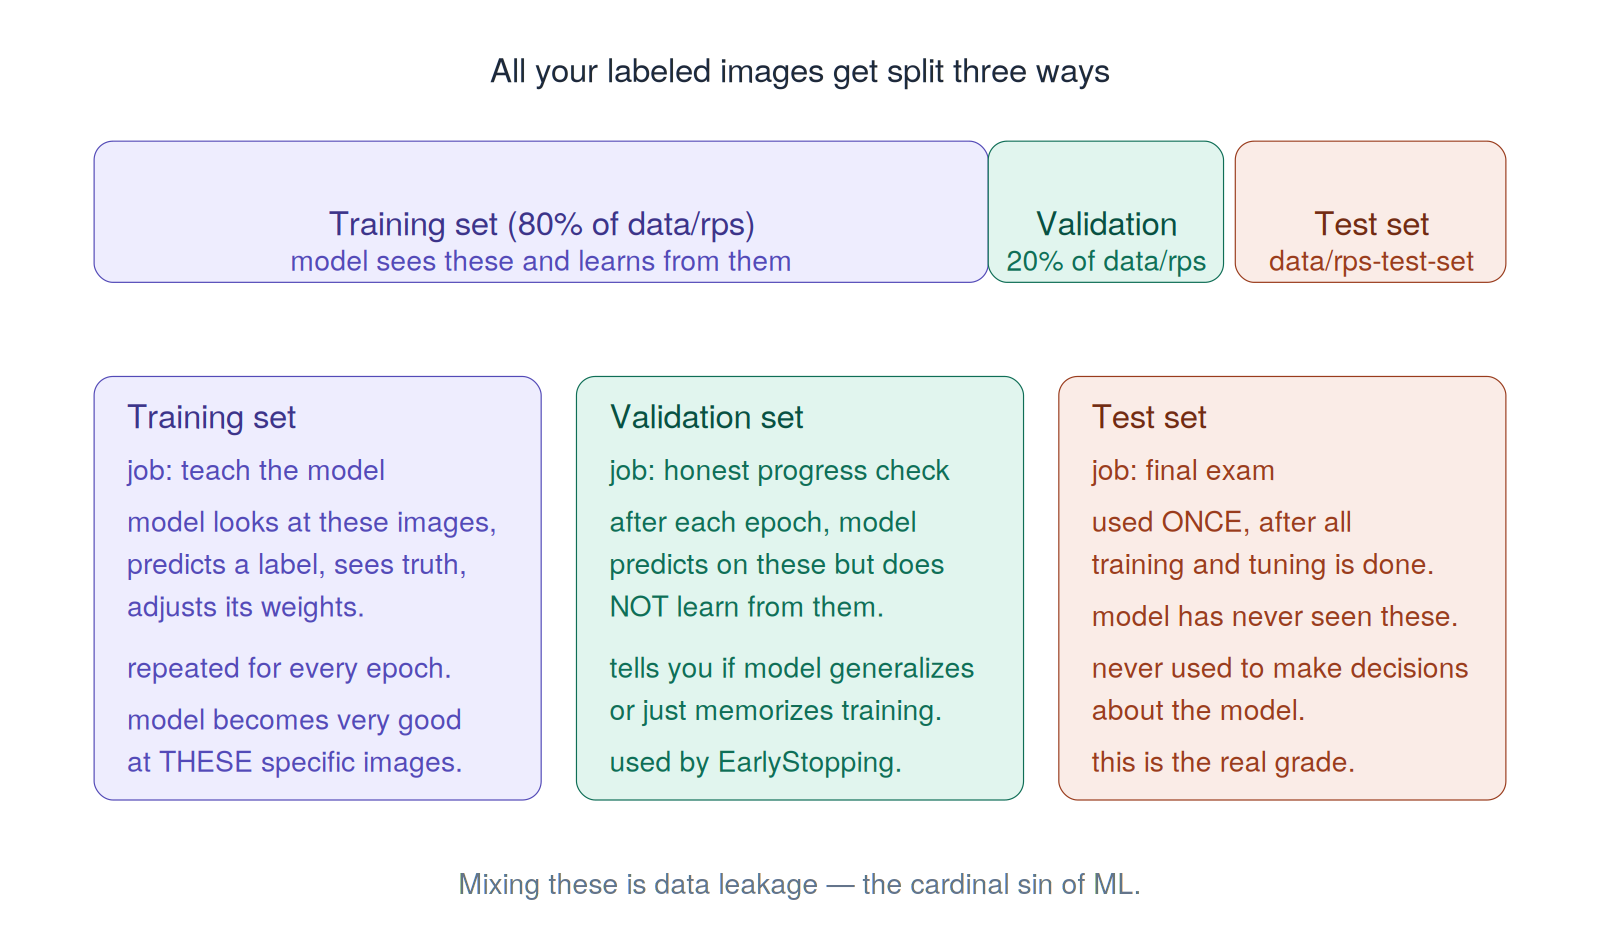

*Three datasets, three different jobs. Mixing them is data leakage.*

Keras has a helper that does the heavy lifting. Point it at a folder; it reads every image, resizes them all to the same size, batches them up, and labels each one based on which subfolder it came from. The expected folder structure:

```
data/rps/
    paper/    ← all paper images go here
    rock/     ← all rock images
    scissors/ ← all scissors images
```

The folder name *becomes* the class label. Alphabetical order: `paper=0, rock=1, scissors=2`.

`validation_split=0.2` means hold out 20% for validation. `subset="training"` says this dataset is the *other* 80%. We'll create a separate dataset object for the validation 20% in the next cell. `seed=42` makes the random split reproducible — same seed, same split every time.

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    'data/rps',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    validation_split=0.2,  # hold out 20% for validation
    seed=42                # reproducible split
)

Now the validation set — same arguments, but `subset="validation"` to grab the 20% that was held back. The seed must match so we get the *complementary* 20% (no overlap with training).

In [ ]:
val_ds = keras.utils.image_dataset_from_directory(
    'data/rps',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    validation_split=0.2,
    seed=42
)

Test data lives in a completely separate folder (`data/rps-test-set`). No `validation_split` here — we want all of it. These images stay sealed in a vault until the very end.

In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    'data/rps-test-set',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Keras inferred the class names from the folder names. Let's grab them — we'll need this list at prediction time to convert numeric labels back to human-readable names.

In [ ]:
class_names = train_ds.class_names

In [ ]:
class_names  # ['paper', 'rock', 'scissors']  — paper=0, rock=1, scissors=2

And the count of classes — we'll use this to size the final layer of our model. Three classes means three output neurons.

In [ ]:
num_classes = len(train_ds.class_names)  # 3

<a id="part9"></a>
## 9. Optimizing the data pipeline

Training a deep model is slow. The bottleneck isn't always the GPU — sometimes the GPU is sitting idle waiting for the next batch of images to be loaded from disk. Three small operations fix this. They have nothing to do with what the model *learns* — only how fast images flow into it.

**`.cache()`** — after the first time we read these images from disk, keep them in memory. Disk reads are slow (milliseconds per image). RAM reads are fast (microseconds). Without cache, every epoch re-reads every file from disk. With cache, the second epoch onward is essentially free.

**`.shuffle(1000)`** — keep a buffer of 1000 images in memory and randomly pick from it. Why shuffle? Because if our training data is sorted (all paper first, then all rock, then all scissors), the model would see only paper images in the first third of each epoch, then only rock — causing wild swings in the weights. Shuffling forces variety. We only shuffle the *training* set; for validation and test, order doesn't matter.

**`.prefetch(AUTOTUNE)`** — while the GPU processes batch N, the CPU should already be loading batch N+1 in the background. Without prefetch, the GPU waits idle. `AUTOTUNE` lets TensorFlow figure out the optimal buffer size.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

<a id="part10"></a>
## 10. Data augmentation — getting more from less


**The problem**: with only a few hundred images per class, the model can *memorize* them — it learns "image #47 is rock" instead of "rocks have a closed-fist shape." This is called **overfitting**. The model aces training but fails on new photos.

**The trick**: every time the model sees a training image, randomly modify it slightly. Flip it left-to-right. Rotate it a bit. Zoom in or out. Now the model never sees the *exact* same image twice. From the model's perspective, the dataset just got infinitely larger and more varied.

The transformations:
- **`RandomFlip("horizontal")`** — mirror the image left-to-right (a hand still looks like a hand mirrored).
- **`RandomRotation(0.2)`** — rotate by up to ±20% of a full circle (about ±72°).
- **`RandomZoom(0.2)`** — zoom in or out by up to ±20%.

**Important**: data augmentation *only runs during training*. Keras automatically disables it during validation, test, and prediction. We don't want random rotation when grading the model — that would make scores noisy and meaningless.

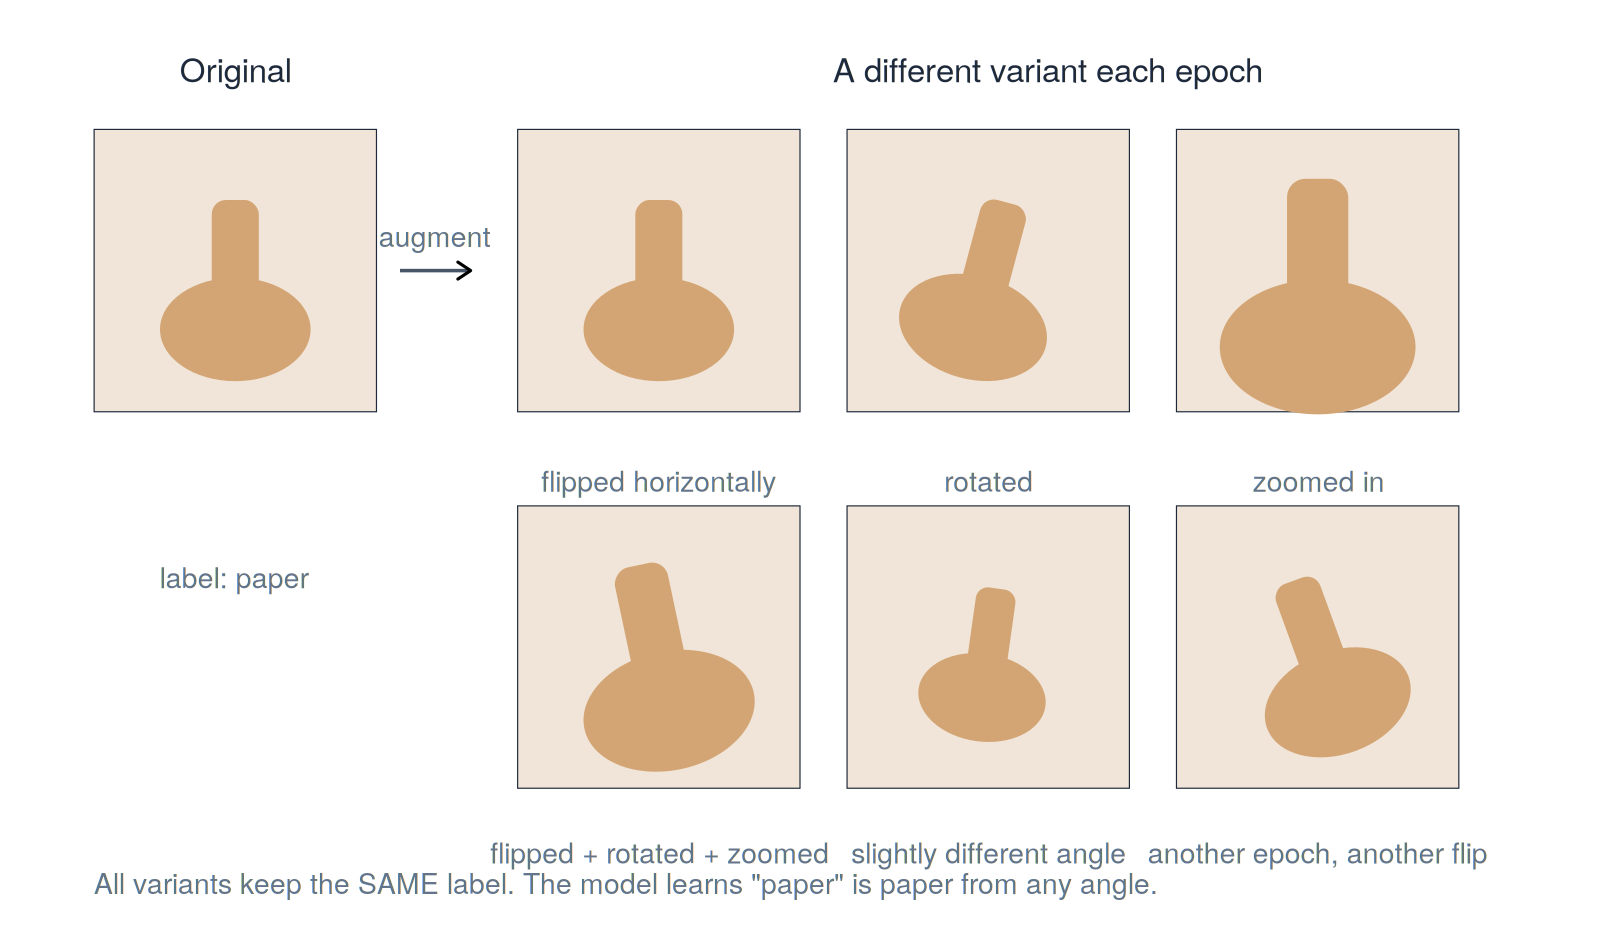

*One image becomes a different variant every epoch. The model sees infinite variety.*

In [ ]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

<a id="part11"></a>
## 11. Building the CNN — every layer dissected


Here is our complete model. `keras.Sequential` means the data flows top-to-bottom — output of each layer becomes input to the next. Simplest possible topology, like a straight pipe.

Look at the diagram on the left. Notice the pattern:
- **Spatial size shrinks**: 150 → 75 → 37 → 18 → 9 (each pooling halves it)
- **Channel depth grows**: 3 → 32 → 64 → 128 → 128 (more filters per layer)

We trade *where* something is for *what* it is. Deeper layers know less about position but more about content. After 4 conv+pool blocks, we flatten the 9×9×128 tensor into a 1D vector of 10,368 numbers, then feed it to dense layers that produce 3 probabilities.

We'll dissect every layer below.

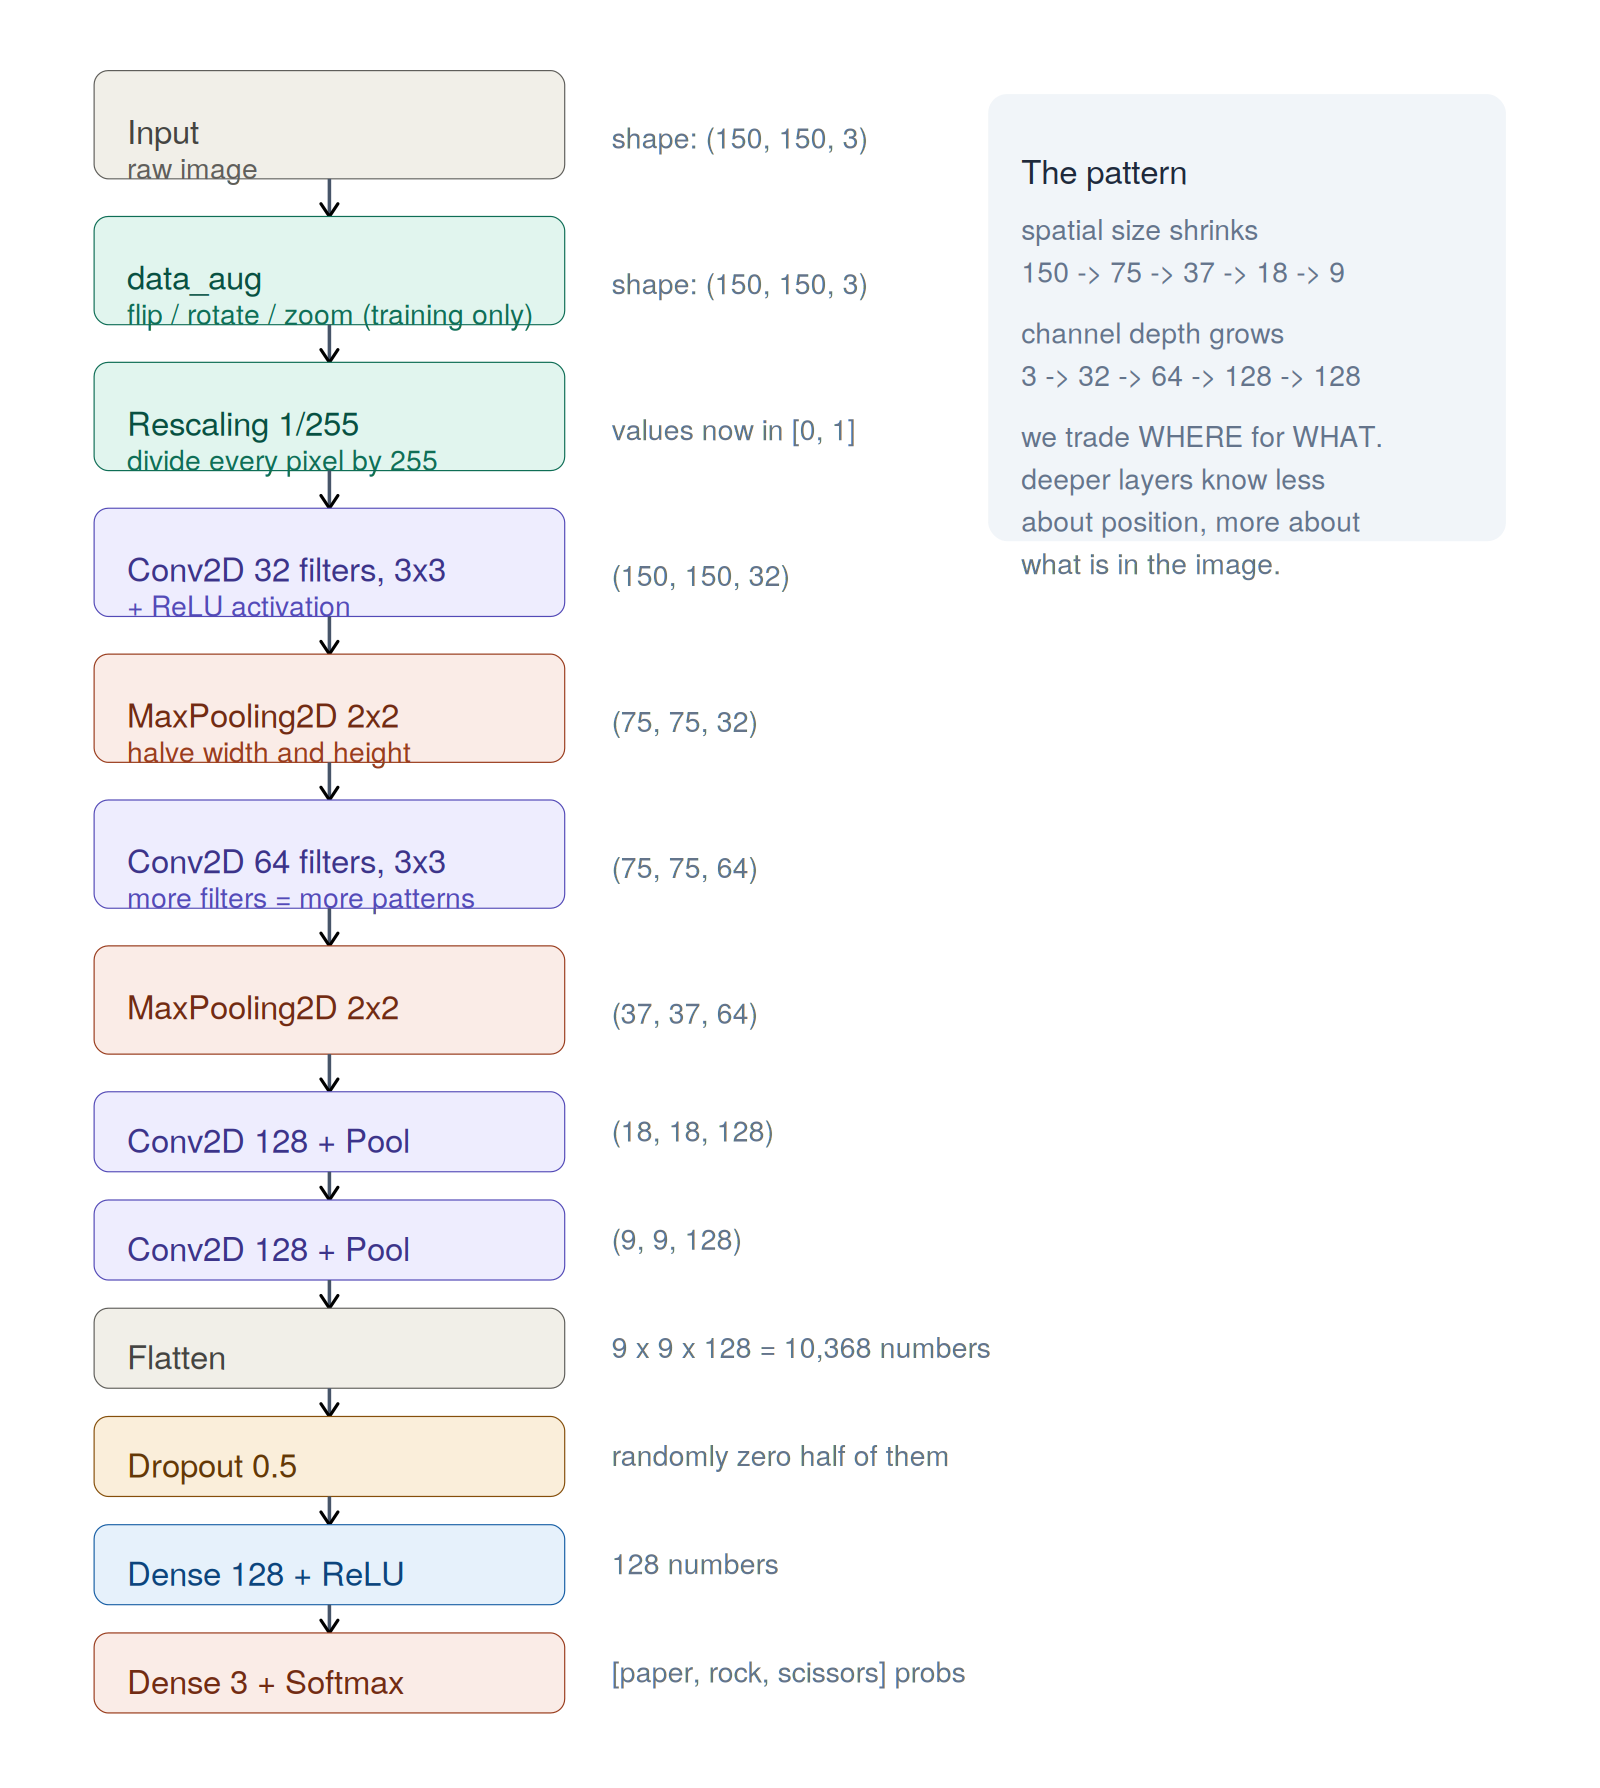

*Every layer's purpose and the resulting tensor shape.*

### Layer-by-layer explanation

**`layers.Input(shape=(150, 150, 3))`** — declares the input shape. Not a "real" layer with weights — it just tells Keras what to expect.

**`data_aug`** — our augmentation block from above. Active only during training. (It's a Sequential model nested inside another Sequential model — totally legal.)

**`layers.Rescaling(1.0/255)`** — divide every pixel by 255 so values go from `[0, 255]` to `[0, 1]`. Neural networks learn much better when inputs are small numbers near zero.

**`layers.Conv2D(32, 3, padding="same", activation="relu")`** — the heart of the CNN. Let's break down every argument:
- `32` = number of filters. Each filter learns one pattern. 32 means we can detect 32 different patterns simultaneously. The output of this layer has 32 channels.
- `3` = filter size (3×3). Small window. We'll cover larger areas by stacking layers.
- `padding="same"` = output has the same width and height as input. Without padding, sliding a 3×3 filter would shrink each side by 1 pixel (the filter can't center on the very edge). Padding adds a ring of zeros so the math works out and we keep 150×150.
- `activation="relu"` = after computing the convolution, apply ReLU to every output number.

**`layers.MaxPooling2D()`** — slides a 2×2 window over the feature map and keeps only the max value in each window. Halves both height and width. Three things happen at once: spatial size shrinks (faster downstream training), strongest signals win (opposite of averaging), and the model becomes a bit position-invariant.

We repeat conv → pool four times, doubling the filter count each time (32 → 64 → 128 → 128). Why? Early layers detect simple things — 32 is plenty. Deeper layers detect more complex patterns and there are vastly more of them. Doubling channels roughly compensates for the spatial halving so total compute stays manageable.

**`layers.Flatten()`** — pure reshape. The tensor is `(9, 9, 128)` after the last pool. Flatten unrolls it into a 1D vector of 9 × 9 × 128 = 10,368 numbers. Bridge from spatial features to general features.

**`layers.Dropout(0.5)`** — randomly turn off 50% of the neurons during each training step. Sounds insane but works: prevents the model from relying on any single neuron, forcing redundancy and robustness. Active only during training; at inference all neurons are live.

**`layers.Dense(128, activation="relu")`** — a fully-connected layer with 128 output neurons. Each neuron is connected to all 10,368 inputs from Flatten. Total parameters: 10,368 × 128 + 128 = 1,327,232. This single layer has most of the weights in the entire model.

**`layers.Dense(num_classes, activation="softmax")`** — the output layer. `num_classes = 3`, so 3 neurons (one per class). The softmax activation converts the 3 raw scores into probabilities that sum to 1.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_aug,
    layers.Rescaling(1.0/255),

    # Conv block 1: 32 filters, halve spatially
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Conv block 2: 64 filters
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Conv block 3: 128 filters
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Conv block 4: 128 filters
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Classifier head
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

### Side-quest: ReLU explained

ReLU (Rectified Linear Unit) is the activation function used after every Conv2D and Dense layer in our model (except the final softmax). The formula is comically simple:

`f(x) = max(0, x)` — if x is negative, output 0. If positive, output x unchanged.

**Why does this matter so much?** Without a *nonlinear* function between layers, stacking layers does nothing useful. Two linear layers in a row collapse mathematically into one linear layer (matrix multiplication is associative). You'd have a deep network with the power of a one-layer network.

ReLU's "kink" at x=0 breaks linearity. Repeated across millions of neurons, that kink lets the network approximate arbitrarily complex functions like "is this image rock, paper, or scissors?".

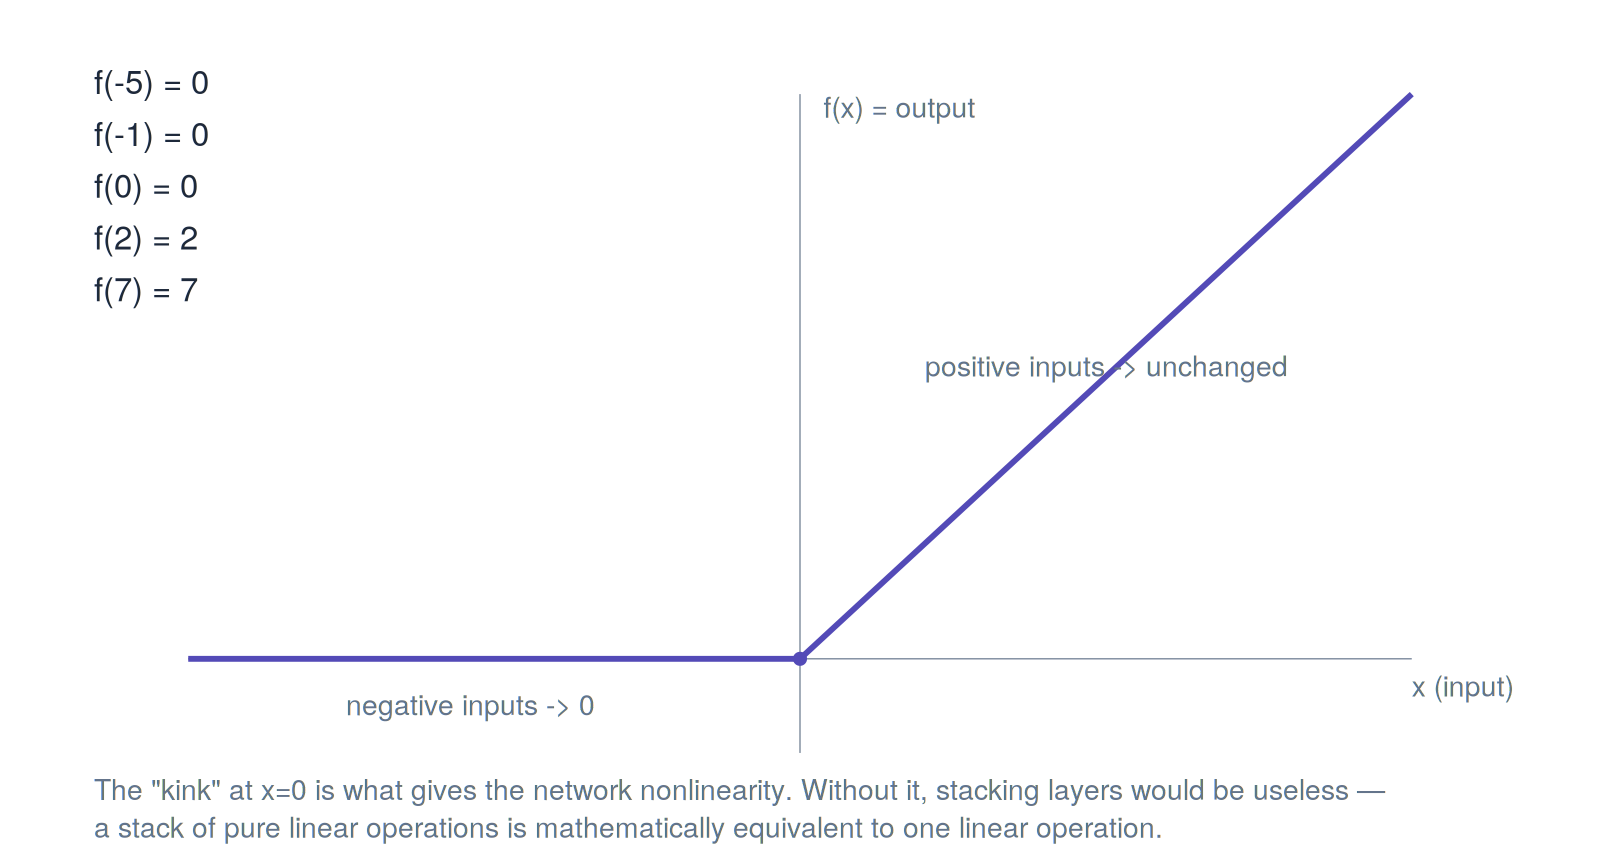

*ReLU: zero out the negatives, leave the positives alone.*

### Side-quest: Max pooling explained

After every conv layer, we shrink the feature map. Max pooling slides a 2×2 window across and keeps only the maximum value in each window.

Why max and not average? Average dilutes — a strong signal mixed with weak signals becomes mediocre. Max preserves — if any pixel in the window detected the pattern strongly, that strength survives.

Three things happen at once: spatial size halves (so faster compute next), strongest signals win, and the model gets a bit of *translation invariance* — if the hand shifts by 1 pixel in the input, the maxes barely change.

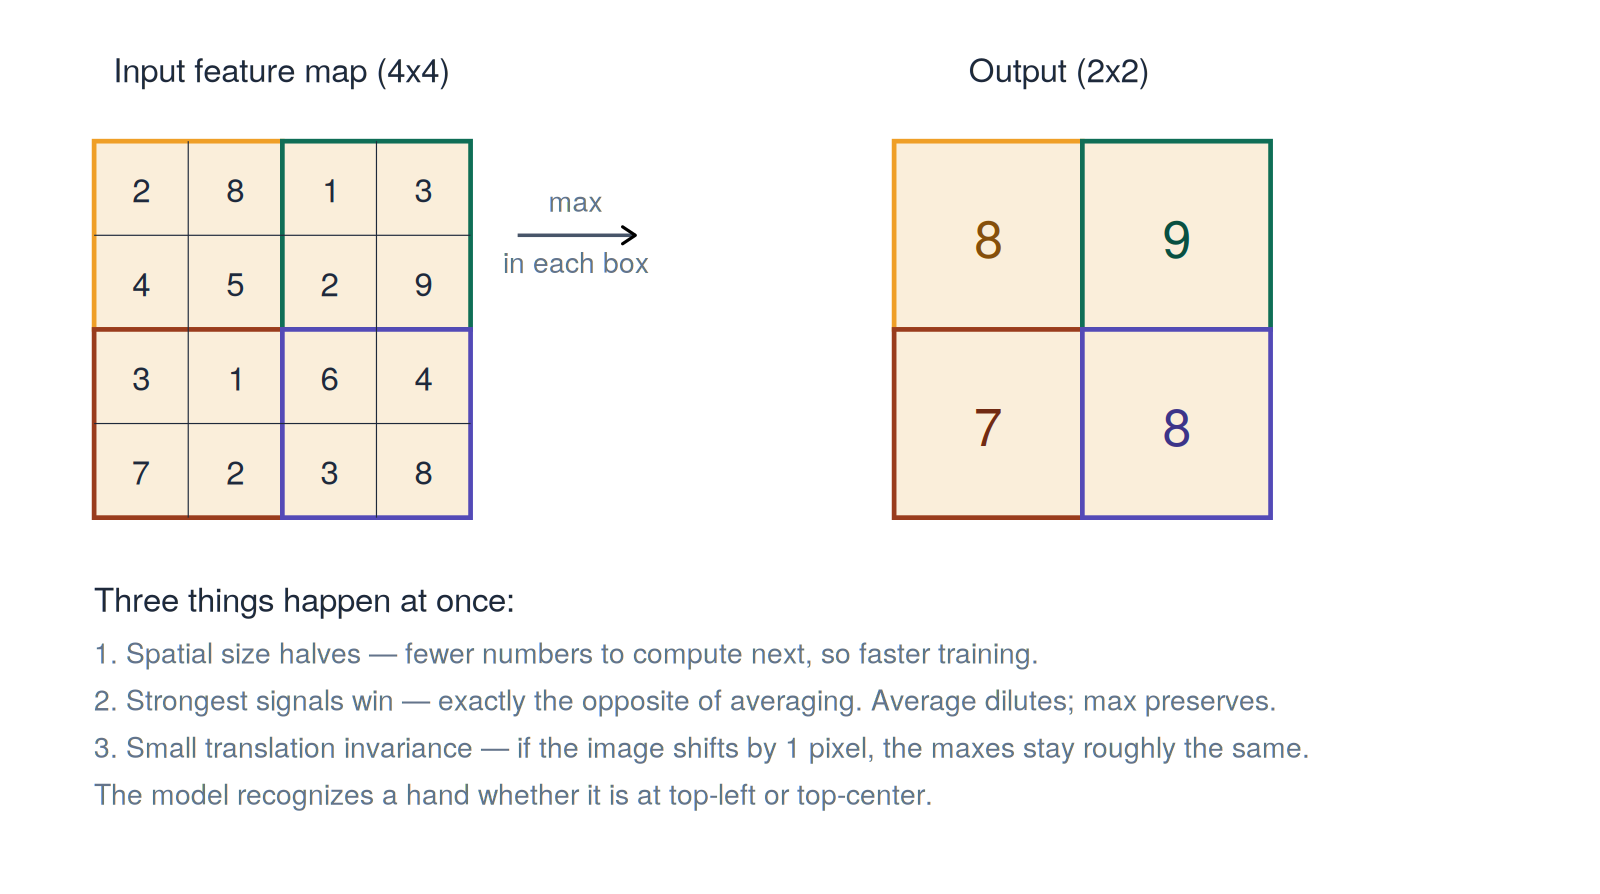

*Max pooling: take the biggest signal in each 2x2 region.*

### Side-quest: Softmax explained

The final Dense layer outputs 3 raw numbers called *logits*. They can be anything: positive, negative, large, small. Not probabilities yet.

**Softmax** converts them into 3 probabilities that sum to exactly 1.0. It does it in two steps:
1. Exponentiate each: `e^x`. This makes them all positive and amplifies differences.
2. Divide each by the sum of all exponentials. Now they sum to 1.

The class with the highest probability is our prediction. The probability itself is the model's confidence.

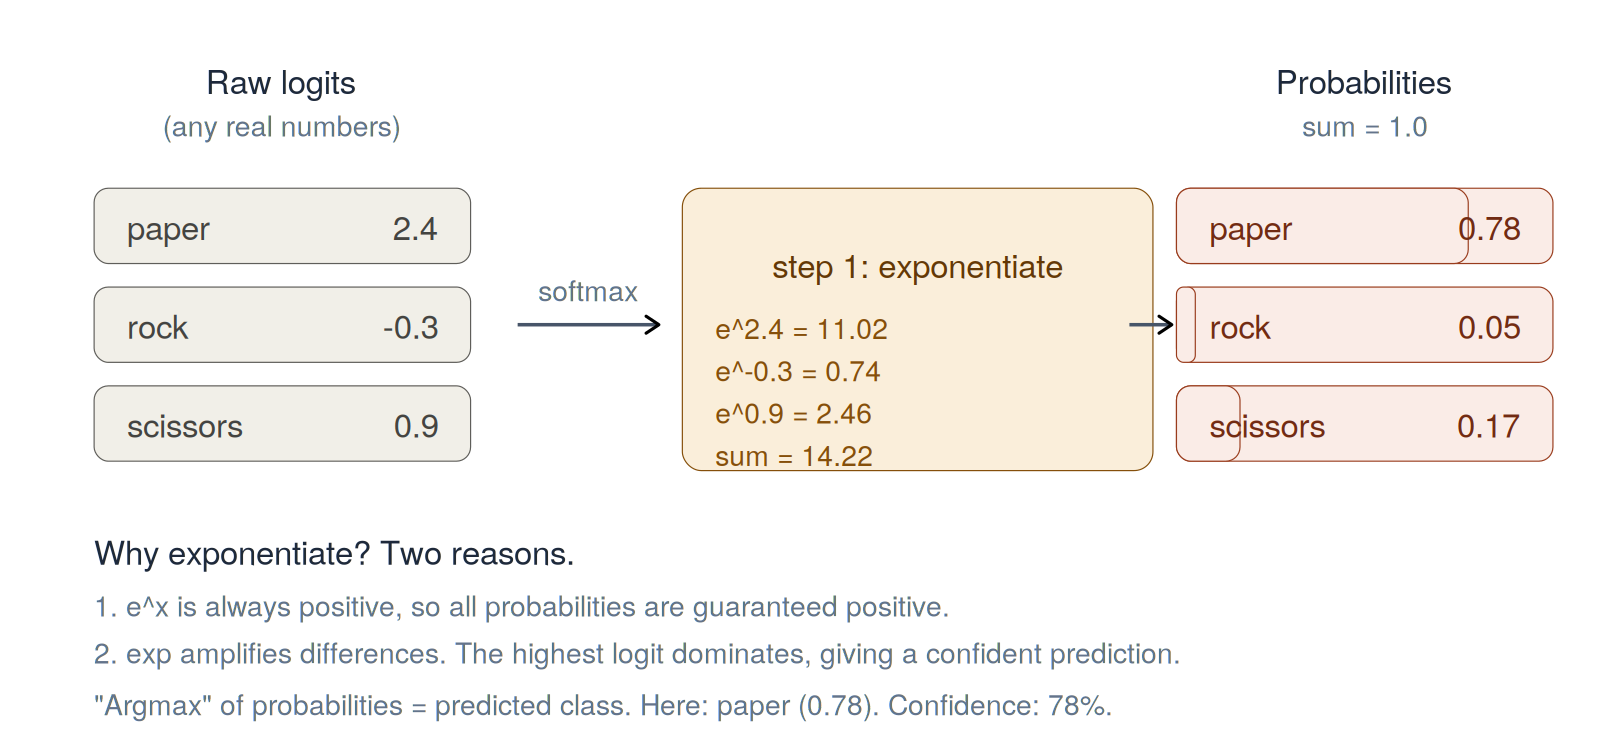

*Softmax: turn arbitrary scores into a clean probability distribution.*

<a id="part12"></a>
## 12. Compiling — loss, optimizer, metrics

We've described the model's architecture. Now we tell Keras *how to train it*. Three pieces:

### Loss function — `sparse_categorical_crossentropy`

The **loss** is a single number that says "how wrong was the prediction?" Lower is better. Training is literally the process of nudging weights to make this number smaller.

For classification, the standard loss is **cross-entropy**. The intuition: it punishes the model heavily when it's confidently wrong, and lightly when it's hesitantly wrong.

If the true class is "paper" and the model predicts probabilities `[0.78, 0.05, 0.17]`, cross-entropy looks at only the probability assigned to the true class (0.78) and computes `−log(0.78) ≈ 0.25`. Small loss, good.

If the model had predicted `[0.05, 0.78, 0.17]` instead (confidently wrong, says rock), the loss is `−log(0.05) ≈ 3.0`. Big loss, bad.

The `sparse_` prefix means our labels are integers (0, 1, 2) rather than one-hot vectors (`[1,0,0]`, `[0,1,0]`, `[0,0,1]`). It's the right choice when `image_dataset_from_directory` gives you integer labels — which it does.

### Optimizer — `adam`

The optimizer is the algorithm that updates weights based on the gradient of the loss. **Adam** is a smart variant that adds momentum (running average of recent gradients) and adapts the step size for each individual weight automatically. In practice it "just works" without tuning. Every modern beginner notebook uses Adam for this reason.

### Metrics — `accuracy`

Loss is what the model optimizes. Accuracy is what humans understand. We optimize loss but report accuracy on the side. Loss is continuous and differentiable; accuracy is discrete (correct/wrong) so you can't directly compute gradients on it.

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Optional: print a summary of the model. Shows every layer, output shape, and parameter count. Very useful for spotting bugs (e.g. wrong tensor shapes) before training.

In [ ]:
model.summary()

<a id="part13"></a>
## 13. Training — the forward and backward pass


This is the heart of deep learning. For every batch of 32 images, four steps happen:

1. **Forward pass**: feed the 32 images through the network. Out comes 32 prediction vectors of shape `[3]` (one probability per class).

2. **Compute loss**: compare each prediction to its true label using cross-entropy. Average across the batch. We get one number — the batch loss.

3. **Backward pass (backpropagation)**: TensorFlow automatically computes how each weight contributed to that loss — the *gradient*. The gradient tells us, for each weight: "if I nudge you up a tiny bit, does the loss go up or down?"

4. **Update**: the optimizer (Adam) pushes each weight in the direction that reduces loss, by a small amount.

Repeat thousands of times across many epochs. The weights gradually become better and better at producing correct predictions.

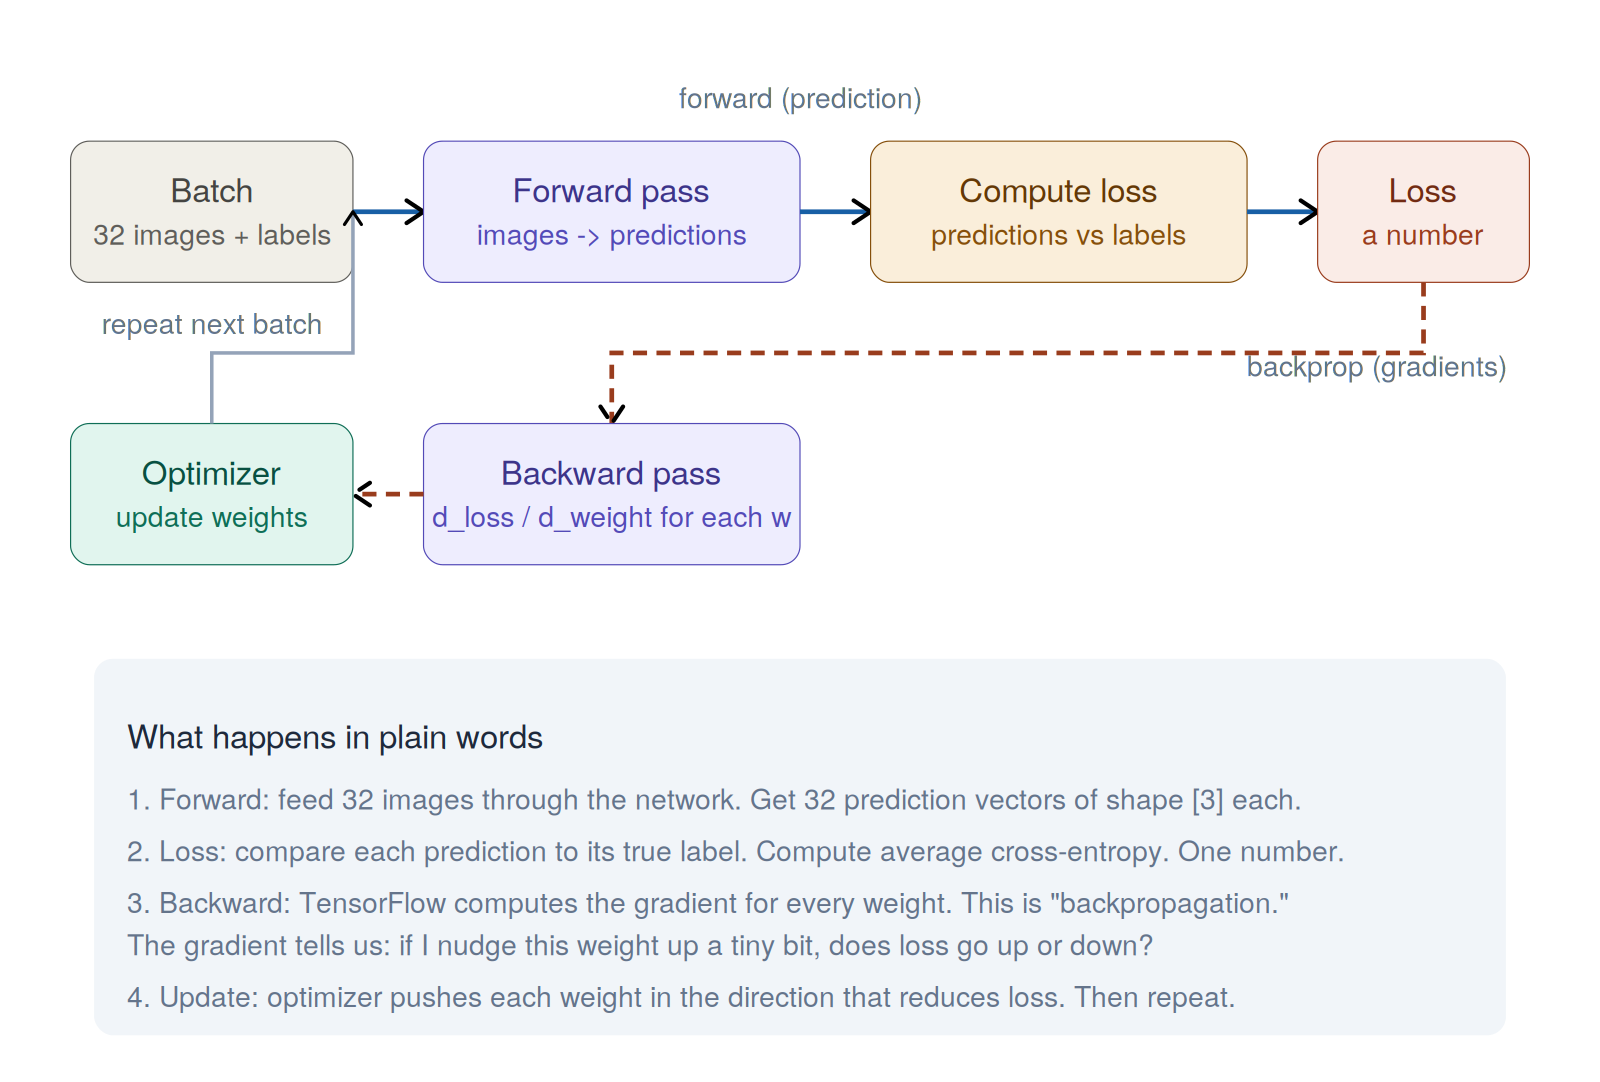

*Forward → loss → backward → update. Repeat for every batch.*

**Vocabulary check:**
- **Batch**: a group of 32 images processed together.
- **Step**: one forward+backward pass on one batch.
- **Epoch**: one full pass through the entire training set. If you have 2000 training images and batch size 32, that's about 63 steps per epoch.

**Key arguments to `model.fit`:**
- `train_ds` — our augmented, shuffled, cached training data.
- `validation_data=val_ds` — at the end of each epoch, run on validation and report `val_loss` and `val_accuracy`. The model does NOT learn from validation.
- `epochs=50` — pass through the training set up to 50 times.
- `callbacks` — hooks that run at certain moments during training.

**EarlyStopping**: a callback that watches the validation loss and stops training when it stops improving. `patience=5` means: if `val_loss` doesn't improve for 5 consecutive epochs, stop. This prevents overfitting (continuing to train past the sweet spot).

`restore_best_weights=True` is critical: when training stops, Keras rolls the model back to whichever epoch had the lowest validation loss. We always end with our best-ever model.

The `history` object captures all per-epoch numbers (training loss, training accuracy, validation loss, validation accuracy). We'll plot it shortly.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ]
)

<a id="part14"></a>
## 14. Evaluating on the test set

This is the moment of truth. The test set has been sealed since the beginning — the model has never seen these images, in any form. Now we run it once and get the honest grade.

If `test_acc` matches your validation accuracy, your model generalizes well. If it's much lower than training accuracy, you overfit.

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

In [ ]:
test_acc

<a id="part15"></a>
## 15. Reading training curves


The four arrays in `history.history` have one number per epoch. Plotting them is how you *diagnose* your model:

- **Good fit**: both training and validation loss fall together and plateau. The gap between them stays small. Ship it.
- **Overfit**: training loss keeps falling but validation loss starts rising. The model is memorizing training images instead of learning concepts. Cure: more data, more augmentation, more dropout, smaller model, or stop earlier.
- **Underfit**: both losses stay stuck high. The model isn't powerful enough. Cure: bigger model, train longer, less regularization.

When you run the cell below, look at the gap between the train (solid) and val (dashed) curves. **That gap is the entire story.** Small gap = generalizing. Big gap = overfitting.

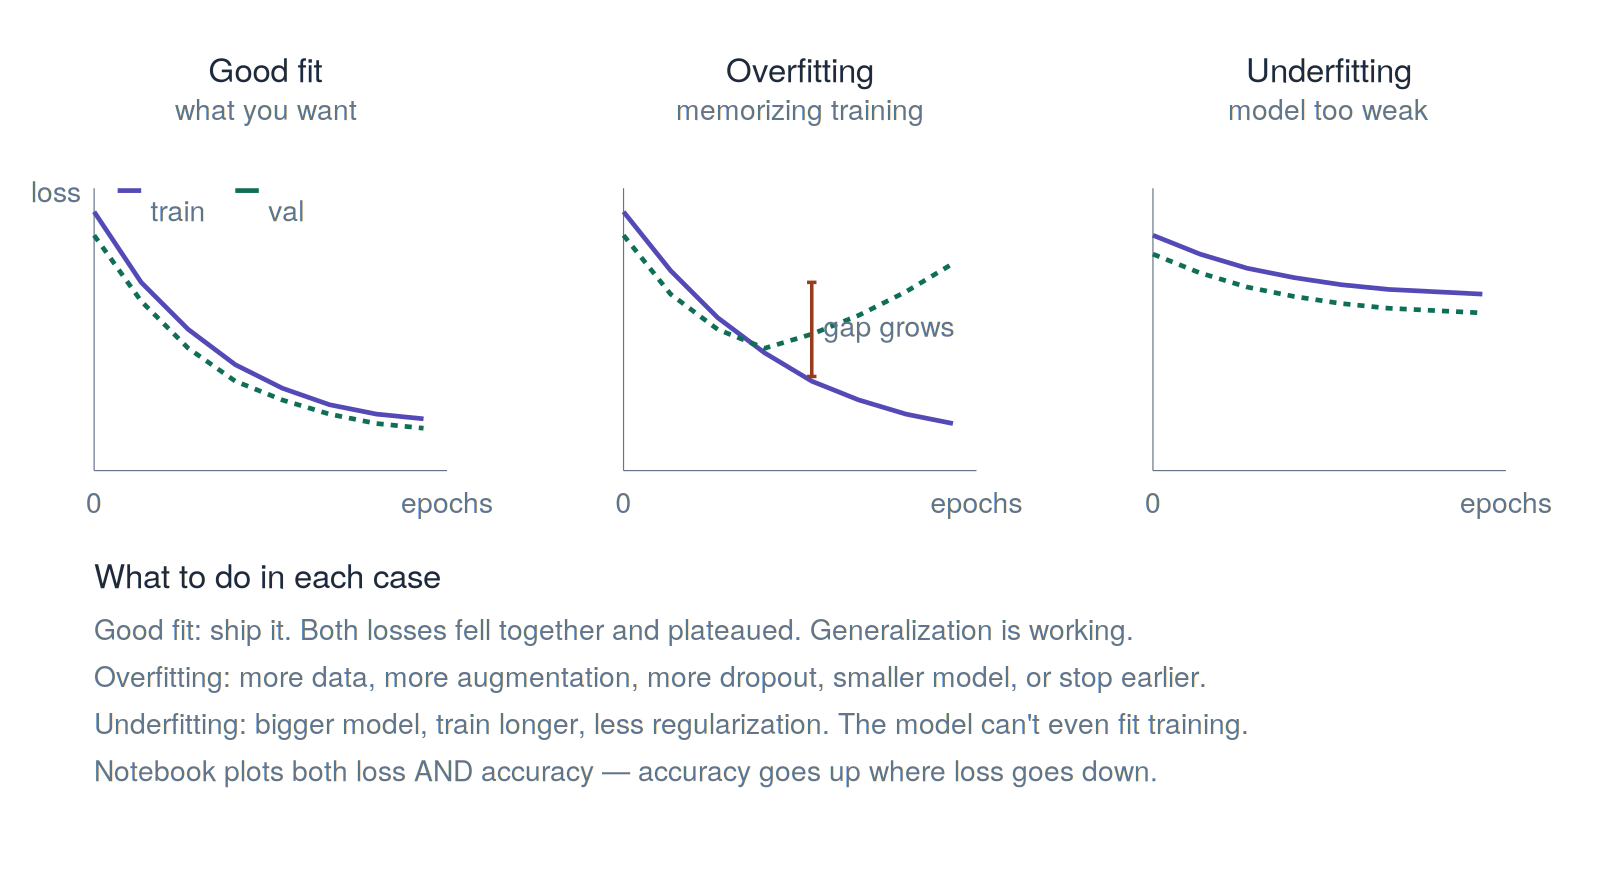

*Three diagnostic shapes: good fit, overfit, underfit. Watch the gap between train and val.*

Pull the per-epoch numbers out of `history.history`:

In [ ]:
acc      = history.history["accuracy"]      # training accuracy per epoch
val_acc  = history.history["val_accuracy"]  # validation accuracy per epoch
loss     = history.history["loss"]          # training loss per epoch
val_loss = history.history["val_loss"]      # validation loss per epoch

Now plot two side-by-side charts: accuracy on the left, loss on the right. Each chart shows both the training curve and the validation curve.

The matplotlib code is standard plotting boilerplate, not deep-learning specific:
- `plt.figure(figsize=(12, 4))` — make a wide figure
- `plt.subplot(1, 2, 1)` — 1 row, 2 columns of plots, draw on plot #1
- `plt.plot(...)` — draw a line
- `plt.legend(...)`, `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)` — labels

In [ ]:
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

# Left chart: accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Right chart: loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

<a id="part16"></a>
## 16. Saving the model

One line. This writes the entire trained model to a single file: architecture, weights, optimizer state, everything.

Later, anywhere — a different script, a different machine, a web server — you can do `model = keras.models.load_model("rps_cnn.keras")` and get back the *exact* same model. This is how you ship a model to production: train once, save, deploy.

The `.keras` extension is the modern Keras format. You may also see `.h5` (older HDF5 format) in legacy code.

In [ ]:
model.save("rps_cnn.keras")

<a id="part17"></a>
## 17. Predicting on a new image

Now the payoff: use our trained model on a single new image it has never seen.

The pipeline:

1. **Load the image** with `keras.utils.load_img`, resizing to `(150, 150)` — exactly what the model expects.
2. **Convert to array** with `keras.utils.img_to_array` — gives shape `(150, 150, 3)`.
3. **Add a batch dimension** with `tf.expand_dims(..., 0)` — turns shape `(150, 150, 3)` into `(1, 150, 150, 3)`. The model always expects a batch, even when you only have one image. This is the most common bug for beginners.
4. **Forward pass** with `model.predict` — returns an array of shape `(1, 3)`: one row of three probabilities.
5. **Interpret**: `argmax` gives the index of the highest probability (0, 1, or 2). Look up that index in `class_names` to get the human-readable label.

In [ ]:
import numpy as np

img_path = "paper01-000.png"  # any image of a hand gesture

# 1. Load and resize
img = keras.utils.load_img(img_path, target_size=(150, 150))

# 2. Convert to numeric array
img_array = keras.utils.img_to_array(img)        # shape (150, 150, 3)

# 3. Add the batch dimension
img_array = tf.expand_dims(img_array, 0)         # shape (1, 150, 150, 3)

# 4. Run the forward pass
predictions = model.predict(img_array)           # shape (1, 3)

# 5. Interpret
predicted_class = class_names[np.argmax(predictions[0])]
confidence = 100 * np.max(predictions[0])

print(f"Prediction: {predicted_class}  ({confidence:.1f}% confidence)")
print(f"Raw probabilities: {dict(zip(class_names, predictions[0]))}")

<a id="part18"></a>
## 18. Where to go from here

You just built, trained, evaluated, saved, and used your first CNN. Take a moment — that's a real accomplishment.

### Three layers of understanding to take with you

**The mechanical workflow**: load data → build model with layers → compile → fit → evaluate → save → predict. Every Keras image project follows this exact skeleton. You can now read most beginner CNN code on the internet.

**The architectural intuition**: convolutions detect patterns by sliding filters, pooling shrinks spatial size while preserving strong signals, dense layers map features to decisions, softmax gives probabilities.

**The training intuition**: forward pass produces a prediction, loss measures how wrong it is, backprop computes how each weight contributed, the optimizer pushes weights to reduce future loss. Everything else — Adam, dropout, augmentation, early stopping — is either a way to compute that gradient step better, or a way to stop the model from memorizing instead of generalizing.

### Improve THIS model

- **Transfer learning**: instead of training from scratch, start with a model pretrained on millions of images (MobileNet, ResNet, EfficientNet) and only fine-tune the top layers. Usually pushes accuracy from ~95% to 99%.
- **Tune hyperparameters**: try different learning rates, batch sizes, dropout amounts.
- **Batch normalization**: add `layers.BatchNormalization()` between Conv and ReLU for faster, more stable training.
- **More augmentation**: add `RandomBrightness`, `RandomContrast`, `RandomTranslation`.
- **More data**: collect more diverse training images — different lighting, skin tones, hand shapes.

### Other computer vision tasks

- **Object detection** (where is it?) — YOLO, Faster R-CNN
- **Image segmentation** (which pixels?) — U-Net
- **Image generation** (create new images) — GANs, diffusion models
- **Vision transformers** — the modern alternative to CNNs

### Foundations to deepen

- **Linear algebra** — matrices, vectors, tensors. The language of all this math.
- **Calculus** — gradients, chain rule. How backpropagation works under the hood.
- **Probability and statistics** — for evaluation, uncertainty, generative models.
- **PyTorch** — the alternative to TensorFlow. Worth knowing both.

---

Keep building. Keep training. Every model you build teaches you more than the last one.